In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#from statannot import add_stat_annotation
import anndata as an
#import diffxpy.api as de
from scipy.stats import hypergeom
import seaborn as sns
import symphonypy as sp
import matplotlib as mpl
from copy import copy
mpl.rc('pdf', fonttype=42)


In [1]:
import sys
sys.path.insert(0, '/home/miri/src/python')
import gene_expression_plots as gep

In [2]:
import matplotlib as mpl
from copy import copy

reds = copy(mpl.cm.Reds)
reds.set_under("lightgray")

In [49]:
adata_pallium= sc.read('/home/labs/reinerlab/miridan/human_development_adata/Cortex_EMX1_louvain3_passedQC_PostM_rev1.h5ad')

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


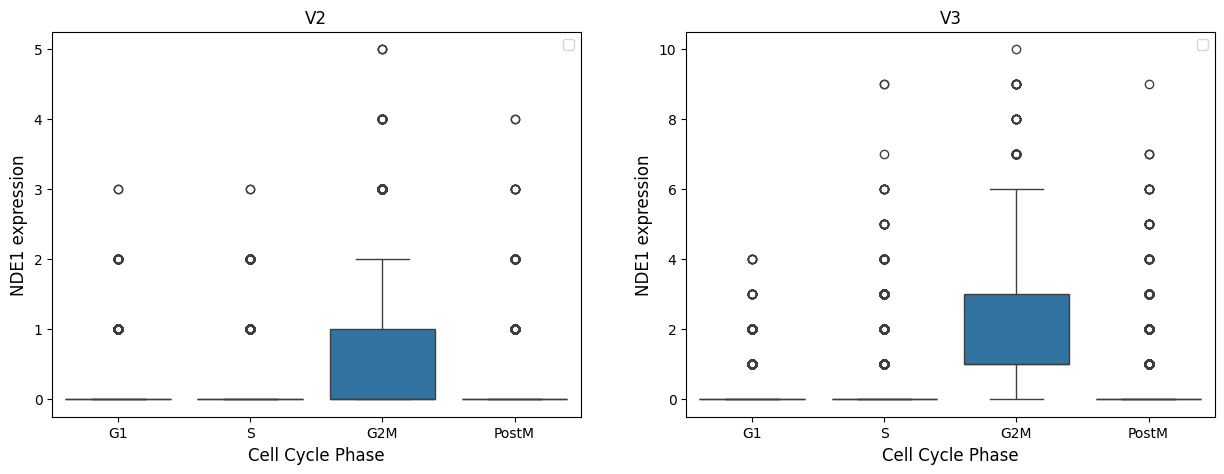

In [16]:
adata_V2 = adata_pallium[np.where(adata_pallium.obs['Chemistry']=='v2')[0],:].copy()
adata_V3 = adata_pallium[np.where(adata_pallium.obs['Chemistry']=='v3')[0],:].copy()

adata_V2.obs['NDE1'] =  adata_V2.X[:,adata_V2.var_names=='NDE1'].toarray().flatten()
adata_V3.obs['NDE1'] =  adata_V3.X[:,adata_V3.var_names=='NDE1'].toarray().flatten()
fig, axs = plt.subplots(1,2,figsize=(15, 5))
ax = sns.boxplot(ax = axs[0],x='CellCyclePhase', y='NDE1',order= ['G1','S','G2M','PostM'] ,data=adata_V2.obs)
axs[0].set_xlabel("Cell Cycle Phase", fontsize= 12)
axs[0].set_ylabel("NDE1 expression", fontsize= 12)
axs[0].set_title("V2", fontsize= 12)
axs[0].grid(False)
axs[0].legend('') 
ax = sns.boxplot(ax = axs[1],x='CellCyclePhase', y='NDE1',order= ['G1','S','G2M','PostM'] ,data=adata_V3.obs)
axs[1].set_xlabel("Cell Cycle Phase", fontsize= 12)
axs[1].set_ylabel("NDE1 expression", fontsize= 12)
axs[1].set_title("V3", fontsize= 12)
axs[1].grid(False)
axs[1].legend('') 

In [ ]:
#Was created using cytograph-shoji (Linarsson Github) from the cell atlas (Braun et al. 2023)
adata_RG_all = sc.read('/home/labs/reinerlab/miridan/human_development_adata/ClassRadialGlia.h5ad')

In [6]:
adata_RG_all

AnnData object with n_obs × n_vars = 519908 × 59480
    obs: 'Age', 'CellClass', 'CellCycleFraction', 'CellCyclePhase', 'Chemistry', 'Clusters', 'Donor', 'DoubletFlag', 'DoubletScore', 'DropletClass', 'MitoFraction', 'NGenes', 'PredictedRegion', 'PrevClusters', 'Region', 'SampleID', 'Sex', 'Subregion', 'Tissue', 'TopLevelCluster', 'TotalUMIs', 'UnsplicedFraction', 'ValidCells'
    var: 'Chromosome', 'End', 'Gene', 'GeneNonzeros', 'GeneTotalUMIs', 'SelectedFeatures', 'Start', 'StdevExpression', 'ValidGenes'
    obsm: 'Embedding', 'Factors'

In [5]:
sc.pp.filter_genes(adata_RG_all, min_cells=3)
#Removed head and brain samples which are not informative for regional information
adata_RG_all = adata_RG_all[~(adata_RG_all.obs.Region=='Brain'),:].copy()
adata_RG_all = adata_RG_all[~(adata_RG_all.obs.Region=='Head'),:].copy()

In [7]:
adata_RG_all.var['highly_variable']= adata_RG_all.var['SelectedFeatures']

In [8]:
adata_RG_all.obs['Region1'] =  adata_RG_all.obs['Region']

In [9]:
adata_RG_all.obs['Region1'][adata_RG_all.obs['Region']=='Pons'] = 'Hindbrain'
adata_RG_all.obs['Region1'][adata_RG_all.obs['Region']=='Medulla'] = 'Hindbrain'
adata_RG_all.obs['Region1'][adata_RG_all.obs['Region']=='Cerebellum'] = 'Hindbrain'
adata_RG_all.obs['Region1'][adata_RG_all.obs['Region']=='Telencephalon'] = 'Forebrain'
adata_RG_all.obs['Region1'][adata_RG_all.obs['Region']=='Diencephalon'] = 'Forebrain'
adata_RG_all.obs['Region1'][adata_RG_all.obs['Region']=='Hippocampus'] = 'Forebrain'


In [11]:
adata_RG_all.layers["counts"] = adata_RG_all.X.copy()
# Normalizing to median total counts
sc.pp.normalize_total(adata_RG_all,target_sum=1e5)
# Logarithmize the data
sc.pp.log1p(adata_RG_all)

sc.pp.scale(adata_RG_all, max_value=10)


In [12]:
sc.tl.pca(adata_RG_all, n_comps=30, zero_center=False,svd_solver='arpack')

In [13]:
sc.pp.neighbors(adata_RG_all, n_neighbors=15)

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/numba/core/cpu.py:99: UserWarning: Numba extension module 'sparse._numba_extension' failed to load due to 'ModuleNotFoundError(No module named 'numba.targets')'.
  numba.core.entrypoints.init_all()
2024-12-24 00:27:51.574427: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-24 00:27:54.559083: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-24 00:27:54.559209: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-24 00:27:54.828

In [14]:
sc.tl.umap(adata_RG_all,min_dist=0.1)

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


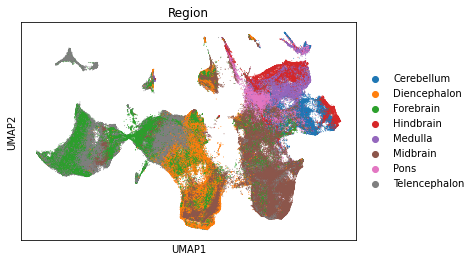

In [15]:
sc.pl.umap(adata_RG_all,color = 'Region',size=3, vmax=2)

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


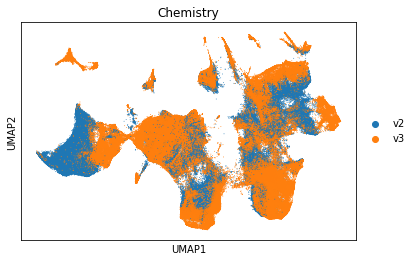

In [16]:
sc.pl.umap(adata_RG_all,color = 'Chemistry',size=3, vmax=2)

In [ ]:
import matplotlib as mpl
from copy import copy

reds = copy(mpl.cm.Reds)
#reds.set_under("lightgray")
adata_ref.obs['Age1'] = adata_ref.obs['Age'].astype(float)
sc.pl.umap(adata_ref,color = 'Age1',size=3 ,cmap=reds, vmin=4.5)

#run_harmony_for_symphony_RG_261124

run_harmony_for_symphony_RG_gt5

In [ ]:
#Output of /home/labs/reinerlab/miridan/src/job_submissions/run_harmony_for_symphony_RG_261124
adata_RG_all = sc.read('/home/labs/reinerlab/miridan/human_development_adata/ClassRadialGlia_for_harmony_symp_2.h5ad')

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [ ]:
#Output of /home/labs/reinerlab/miridan/src/job_submissions/run_harmony_for_symphony_RG_261124
adata_RG_all = sc.read('/miridan-storage/miridan/wexac_backup/human_development_adata//ClassRadialGlia_for_harmony_symp_2.h5ad')

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [20]:
sc.pp.neighbors(adata_RG_all, use_rep="X_pca_harmony", n_neighbors=15)
sc.tl.umap(adata_RG_all,min_dist=0.1)

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


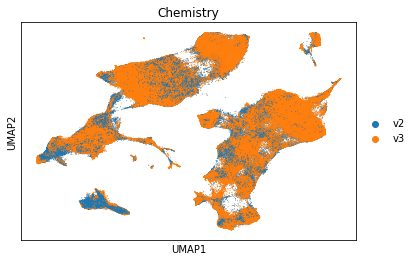

In [21]:
sc.pl.umap(adata_RG_all,color = 'Chemistry',size=3, vmax=2)

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


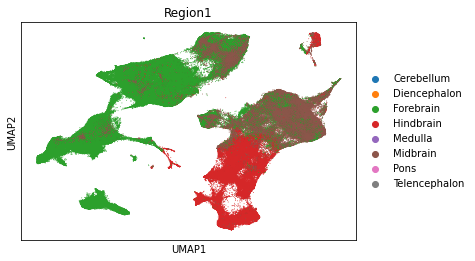

In [22]:
sc.pl.umap(adata_RG_all,color = 'Region1',size=3, vmax=2)

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


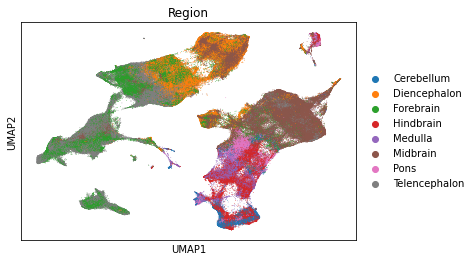

In [23]:
sc.pl.umap(adata_RG_all,color = 'Region',size=2, vmax=2)

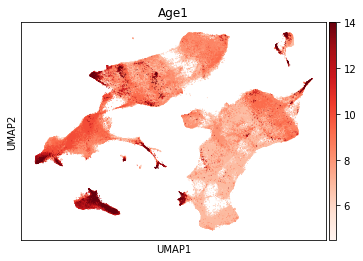

In [24]:
adata_RG_all.obs['Age1'] = adata_RG_all.obs['Age'].astype(float)
reds = copy(mpl.cm.Reds)
sc.pl.umap(adata_RG_all,color = 'Age1',size=3 ,cmap=reds, vmin=4.5)

In [25]:
adata_RG_all.var['Accession'] =  adata_RG_all.var_names

In [26]:
adata_RG_all.var_names =  adata_RG_all.var.Gene

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:956: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['WASH7P', 'CICP27', 'AL627309.6', 'AL627309.5', 'FO538757.1']

    Inferred to be: categorical

  names = self._prep_dim_index(names, "var")


In [27]:
adata_RG_all.obs.CellClass

CellID
10X89_1:AAAGTAGAGACCTTTG     Radial glia
10X89_1:AACCATGGTCACTTCC     Radial glia
10X89_1:AAGACCTGTGCGGTAA     Radial glia
10X89_1:ACACCAAAGATGCCTT     Radial glia
10X89_1:ACACTGACATCAGTAC     Radial glia
                                ...     
10X302_8:TGGGTTATCAGAGTGG    Radial glia
10X302_8:TTCAATCCAGAGGCTA    Radial glia
10X302_8:TTCGATTCATAAGCGG    Radial glia
10X302_8:TTGATGGGTTCCTACC    Radial glia
10X302_8:TTGCTGCCATCCCGTT    Radial glia
Name: CellClass, Length: 477251, dtype: category
Categories (1, object): ['Radial glia']

In [21]:
adata_RG_all.var_names

Index(['WASH7P', 'CICP27', 'AL627309.6', 'AL627309.5', 'FO538757.1', 'WASH9P',
       'AP006222.1', 'AP006222.2', 'AL732372.2', 'AL669831.3',
       ...
       'MT-CYB', 'MT-TT', 'MT-TP', 'BX004987.1', 'AC145212.1', 'AC011043.1',
       'AL354822.1', 'AL592183.1', 'AC240274.1', 'AC136352.4'],
      dtype='object', name='Gene', length=42402)

In [27]:
adata_RG_all.write("/home/labs/reinerlab/miridan/human_development_adata/ClassRadialGlia_for_harmony_symp_22.h5ad")

In [4]:
adata_RG_all = sc.read("/home/labs/reinerlab/miridan/human_development_adata/ClassRadialGlia_for_harmony_symp_22.h5ad",  backed="r")

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


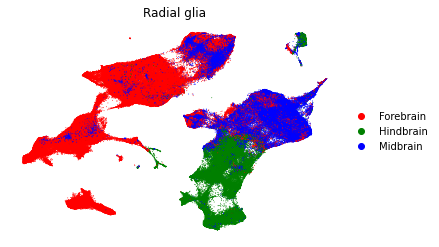

<Figure size 432x288 with 0 Axes>

In [40]:
sc.pl.umap(
    adata_RG_all,
    color="Region1",
    frameon=False,
    title="Radial glia",
    #show=False,
    #legend_loc=None,
    palette={         "Forebrain": "red",         "Midbrain": "blue",         "Hindbrain": "green",           },
    size=3, save = "NDE1_RG_Region1.pdf"
)
plt.savefig('/home/labs/reinerlab/miridan/NDE1/NDE1_RG_Region1.pdf',dpi=200)

In [ ]:
fig, axes = plt.subplots(figsize=(9, 8), ncols=2, nrows = 2)

sc.pl.umap(
    adata_RG_all,
    frameon=False,
    ax=axes[0,0],
    show=False,size=20,legend_loc=None,palette={         "Forebrain": "red",         "Midbrain": "blue",         "Hindbrain": "green",           }
    
)
sc.pl.umap(
    adata_NDE1_raw[adata_NDE1_raw.obs['corrected.ident']=='KO_3',:],
    color="Region1",
    frameon=False,
    title="NDE1 KO3",
    ax=axes[0,0],
    show=False,size=20,legend_loc=None,palette={         "Forebrain": "red",         "Midbrain": "blue",         "Hindbrain": "green",           }
    
)
sc.pl.umap(
    adata_RG_all,
    frameon=False,
    ax=axes[0,1],
    show=False,size=20,legend_loc=None,palette={         "Forebrain": "red",         "Midbrain": "blue",         "Hindbrain": "green",           }
    
)
sc.pl.umap(
    adata_NDE1_raw[adata_NDE1_raw.obs['corrected.ident']=='KO_4',:],
    color="Region1",
    frameon=False,
    title="NDE1 KO4",
    ax=axes[0,1],
    show=False,size=20,legend_loc=None,palette={         "Forebrain": "red",         "Midbrain": "blue",         "Hindbrain": "green",           }
    
)
sc.pl.umap(
    adata_RG_all,
    frameon=False,
    ax=axes[1,0],
    show=False,size=20,legend_loc=None,palette={         "Forebrain": "red",         "Midbrain": "blue",         "Hindbrain": "green",           }
    
)
sc.pl.umap(
    adata_NDE1_raw[adata_NDE1_raw.obs['corrected.ident']=='W3_ep3',:],
    color="Region1",
    frameon=False,
    title="WT 1",
    ax=axes[1,0],
    show=False,size=20,legend_loc=None,palette={         "Forebrain": "red",         "Midbrain": "blue",         "Hindbrain": "green",           }
)
sc.pl.umap(
    adata_RG_all,
    frameon=False,
    ax=axes[1,1],
    show=False,size=20,legend_loc=None,palette={         "Forebrain": "red",         "Midbrain": "blue",         "Hindbrain": "green",           }
    
)
sc.pl.umap(
    adata_NDE1_raw[adata_NDE1_raw.obs['corrected.ident']=='W3_e3',:],
    color="Region1",
    frameon=False,
    title="WT 2",
    ax=axes[1,1],
    show=False,size=20,legend_loc=None,palette={         "Forebrain": "red",         "Midbrain": "blue",         "Hindbrain": "green",           }
)
plt.savefig('/home/labs/reinerlab/miridan/NDE1/NDE1_Region1_gt5.pdf',dpi=200)

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


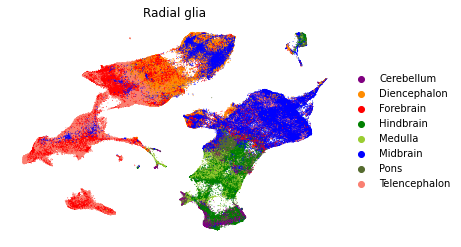

In [13]:
sc.pl.umap(
    adata_RG_all,
    color="Region",
    frameon=False,
    title="Radial glia",
    #show=False,
    #legend_loc=None,
    palette={         "Forebrain": "red", "Telencephalon": "salmon",  "Diencephalon": "darkorange" ,      "Midbrain": "blue",   "Cerebellum":"purple",      "Hindbrain": "green","Pons":"darkolivegreen", "Medulla": "yellowgreen"          },
    size=3,
    save = 'NDE1_RG_Region.pdf'
)
#plt.savefig('/home/labs/reinerlab/miridan/NDE1/NDE1_RG_Region.pdf',dpi=200)

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


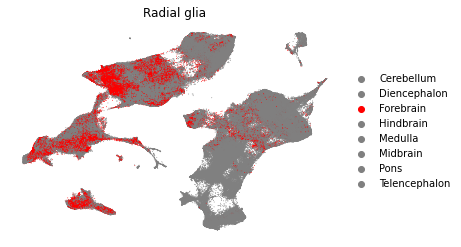

In [12]:
sc.pl.umap(
    adata_RG_all,
    color="Region",
    frameon=False,
    title="Radial glia",
    #show=False,
    #legend_loc=None,
    palette={         "Forebrain": "red", "Telencephalon": "gray",  "Diencephalon": "gray" ,      "Midbrain": "gray",   "Cerebellum":"gray",      "Hindbrain": "gray","Pons":"gray", "Medulla": "gray"          },
    size=3,
   # save = 'NDE1_RG_Region.pdf'
)
#plt.savefig('/home/labs/reinerlab/miridan/NDE1/NDE1_RG_Region.pdf',dpi=200)

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/scanpy/plotting/_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


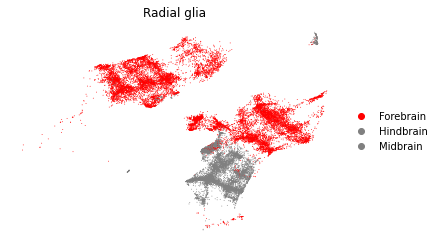

In [12]:
sc.pl.umap(
    adata_RG_all[adata_RG_all.obs['Age']==5,:],
    color="Region",
    frameon=False,
    title="Radial glia",
    #show=False,
    #legend_loc=None,
    palette={         "Forebrain": "red", "Telencephalon": "gray",  "Diencephalon": "gray" ,      "Midbrain": "gray",   "Cerebellum":"gray",      "Hindbrain": "gray","Pons":"gray", "Medulla": "gray"          },
    size=3,
   # save = 'NDE1_RG_Region.pdf'
)

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/scanpy/plotting/_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


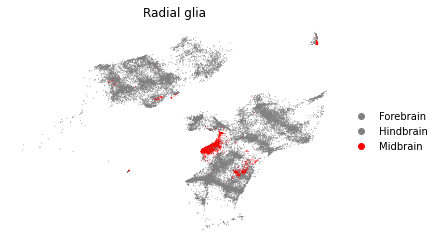

In [4]:
sc.pl.umap(
    adata_RG_all[adata_RG_all.obs['Age']==5,:],
    color="Region",
    frameon=False,
    title="Radial glia",
    #show=False,
    #legend_loc=None,
    palette={         "Midbrain": "red", "Telencephalon": "gray",  "Diencephalon": "gray" ,      "Forebrain": "gray",   "Cerebellum":"gray",      "Hindbrain": "gray","Pons":"gray", "Medulla": "gray"          },
    size=3,
   # save = 'NDE1_RG_Region.pdf'
)

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/scanpy/plotting/_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


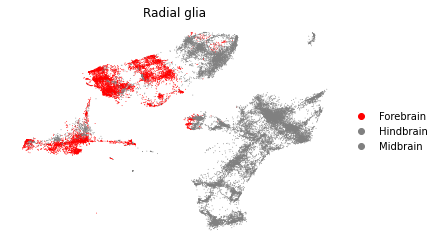

In [13]:
sc.pl.umap(
    adata_RG_all[adata_RG_all.obs['Age']==5.5,:],
    color="Region",
    frameon=False,
    title="Radial glia",
    #show=False,
    #legend_loc=None,
    palette={         "Forebrain": "red", "Telencephalon": "gray",  "Diencephalon": "gray" ,      "Midbrain": "gray",   "Cerebellum":"gray",      "Hindbrain": "gray","Pons":"gray", "Medulla": "gray"          },
    size=3,
   # save = 'NDE1_RG_Region.pdf'
)

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


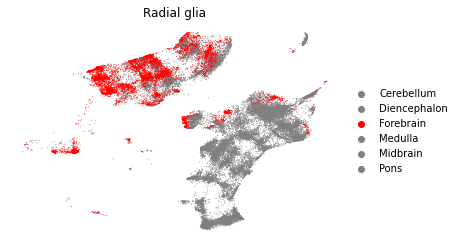

In [11]:
adata_RG_gt_6 = adata_RG_all[adata_RG_all.obs['Age']==6.6,:].copy()
sc.pl.umap(
   adata_RG_gt_6,
    color="Region",
    frameon=False,
    title="Radial glia",
    #show=False,
    #legend_loc=None,
    palette={         "Forebrain": "red", "Telencephalon": "gray",  "Diencephalon": "gray" ,      "Midbrain": "gray",   "Cerebellum":"gray",      "Hindbrain": "gray","Pons":"gray", "Medulla": "gray"          },
    size=3,
   # save = 'NDE1_RG_Region.pdf'
)

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


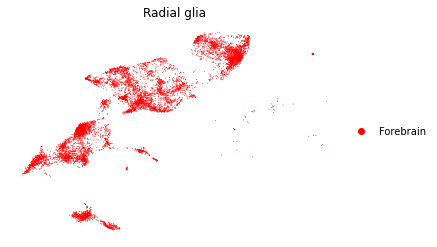

In [14]:
adata_RG_gt_6 = adata_RG_all[adata_RG_all.obs['Age']==7.5,:].copy()
sc.pl.umap(
   adata_RG_gt_6,
    color="Region",
    frameon=False,
    title="Radial glia",
    #show=False,
    #legend_loc=None,
    palette={         "Forebrain": "red", "Telencephalon": "gray",  "Diencephalon": "gray" ,      "Midbrain": "gray",   "Cerebellum":"gray",      "Hindbrain": "gray","Pons":"gray", "Medulla": "gray"          },
    size=3,
   # save = 'NDE1_RG_Region.pdf'
)

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


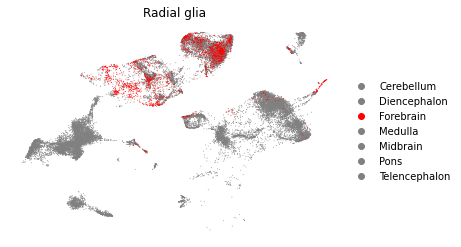

In [15]:
adata_RG_gt_6 = adata_RG_all[adata_RG_all.obs['Age']==8,:].copy()
sc.pl.umap(
   adata_RG_gt_6,
    color="Region",
    frameon=False,
    title="Radial glia",
    #show=False,
    #legend_loc=None,
    palette={         "Forebrain": "red", "Telencephalon": "gray",  "Diencephalon": "gray" ,      "Midbrain": "gray",   "Cerebellum":"gray",      "Hindbrain": "gray","Pons":"gray", "Medulla": "gray"          },
    size=3,
   # save = 'NDE1_RG_Region.pdf'
)

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


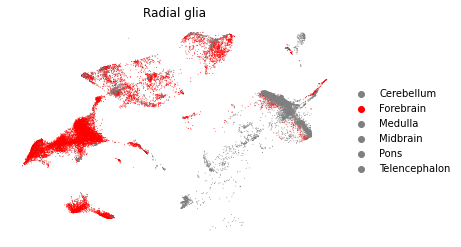

In [16]:
adata_RG_gt_6 = adata_RG_all[adata_RG_all.obs['Age']==8.5,:].copy()
sc.pl.umap(
   adata_RG_gt_6,
    color="Region",
    frameon=False,
    title="Radial glia",
    #show=False,
    #legend_loc=None,
    palette={         "Forebrain": "red", "Telencephalon": "gray",  "Diencephalon": "gray" ,      "Midbrain": "gray",   "Cerebellum":"gray",      "Hindbrain": "gray","Pons":"gray", "Medulla": "gray"          },
    size=3,
   # save = 'NDE1_RG_Region.pdf'
)

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


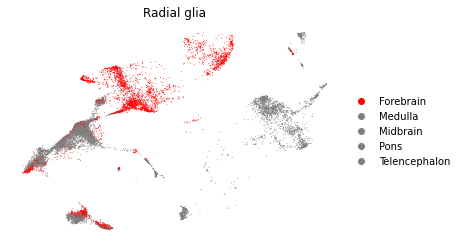

In [17]:
adata_RG_gt_6 = adata_RG_all[adata_RG_all.obs['Age']==9.2,:].copy()
sc.pl.umap(
   adata_RG_gt_6,
    color="Region",
    frameon=False,
    title="Radial glia",
    #show=False,
    #legend_loc=None,
    palette={         "Forebrain": "red", "Telencephalon": "gray",  "Diencephalon": "gray" ,      "Midbrain": "gray",   "Cerebellum":"gray",      "Hindbrain": "gray","Pons":"gray", "Medulla": "gray"          },
    size=3,
   # save = 'NDE1_RG_Region.pdf'
)

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


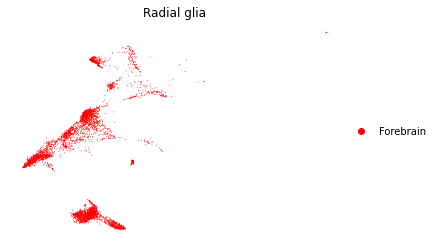

In [18]:
adata_RG_gt_6 = adata_RG_all[adata_RG_all.obs['Age']==9.5,:].copy()
sc.pl.umap(
   adata_RG_gt_6,
    color="Region",
    frameon=False,
    title="Radial glia",
    #show=False,
    #legend_loc=None,
    palette={         "Forebrain": "red", "Telencephalon": "gray",  "Diencephalon": "gray" ,      "Midbrain": "gray",   "Cerebellum":"gray",      "Hindbrain": "gray","Pons":"gray", "Medulla": "gray"          },
    size=3,
   # save = 'NDE1_RG_Region.pdf'
)

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


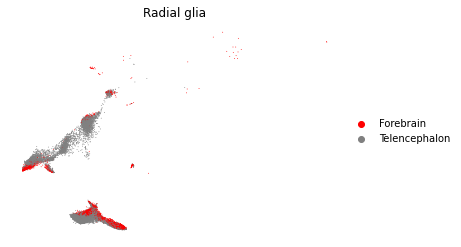

In [19]:
adata_RG_gt_6 = adata_RG_all[adata_RG_all.obs['Age']==10,:].copy()
sc.pl.umap(
   adata_RG_gt_6,
    color="Region",
    frameon=False,
    title="Radial glia",
    #show=False,
    #legend_loc=None,
    palette={         "Forebrain": "red", "Telencephalon": "gray",  "Diencephalon": "gray" ,      "Midbrain": "gray",   "Cerebellum":"gray",      "Hindbrain": "gray","Pons":"gray", "Medulla": "gray"          },
    size=3,
   # save = 'NDE1_RG_Region.pdf'
)

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


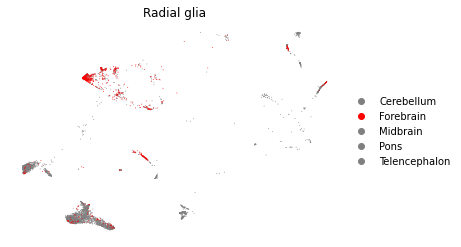

In [20]:
adata_RG_gt_6 = adata_RG_all[adata_RG_all.obs['Age']==11.5,:].copy()
sc.pl.umap(
   adata_RG_gt_6,
    color="Region",
    frameon=False,
    title="Radial glia",
    #show=False,
    #legend_loc=None,
    palette={         "Forebrain": "red", "Telencephalon": "gray",  "Diencephalon": "gray" ,      "Midbrain": "gray",   "Cerebellum":"gray",      "Hindbrain": "gray","Pons":"gray", "Medulla": "gray"          },
    size=3,
   # save = 'NDE1_RG_Region.pdf'
)

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


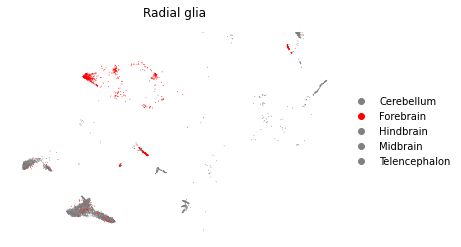

In [21]:
adata_RG_gt_6 = adata_RG_all[adata_RG_all.obs['Age']==12,:].copy()
sc.pl.umap(
   adata_RG_gt_6,
    color="Region",
    frameon=False,
    title="Radial glia",
    #show=False,
    #legend_loc=None,
    palette={         "Forebrain": "red", "Telencephalon": "gray",  "Diencephalon": "gray" ,      "Midbrain": "gray",   "Cerebellum":"gray",      "Hindbrain": "gray","Pons":"gray", "Medulla": "gray"          },
    size=3,
   # save = 'NDE1_RG_Region.pdf'
)

In [10]:
np.unique(adata_RG_all[adata_RG_all.obs['Region']=='Forebrain',:].obs['Age'])

array([ 5. ,  5.5,  6.6,  7.5,  8. ,  8.5,  9.2,  9.5, 10. , 11.5, 12. ,
       13. ], dtype=float32)

In [5]:
#Remove 5 pcw sample from the analysis - probably misdissected
adata_RG_all_gt5 = adata_RG_all[adata_RG_all.obs['Age']!=5,:].to_memory()

In [6]:
adata_RG_all_gt5.write("/home/labs/reinerlab/miridan/human_development_adata/ClassRadialGlia_for_harmony_symp_gt5_2.h5ad")

*run_harmony_for_symphony_RG_gt5*

In [2]:
adata_RG_all_gt5 = sc.read("/home/labs/reinerlab/miridan/human_development_adata/ClassRadialGlia_for_harmony_gt5.h5ad")

/home/labs/reinerlab/miridan/.conda/envs/symphony2/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/home/labs/reinerlab/miridan/.conda/envs/symphony2/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [49]:
umap_w = np.max(adata_RG_all_gt5.obsm['X_pca_harmony'][1])- np.min(adata_RG_all_gt5.obsm['X_pca_harmony'][1])
umap_h = np.max(adata_RG_all_gt5.obsm['X_pca_harmony'][0])- np.min(adata_RG_all_gt5.obsm['X_pca_harmony'][0])
sc.set_figure_params(dpi_save=300, frameon=False, vector_friendly=True, fontsize=20, figsize=(umap_w, umap_h))
                                            

In [46]:
 np.max(adata_RG_all_gt5.obsm['X_pca_harmony'][1])

7.4922633

In [42]:
adata_RG_all_gt5.obsm

AxisArrays with keys: Embedding, Factors, X_pca, X_pca_harmony, X_umap

/home/labs/reinerlab/miridan/.conda/envs/symphony2/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


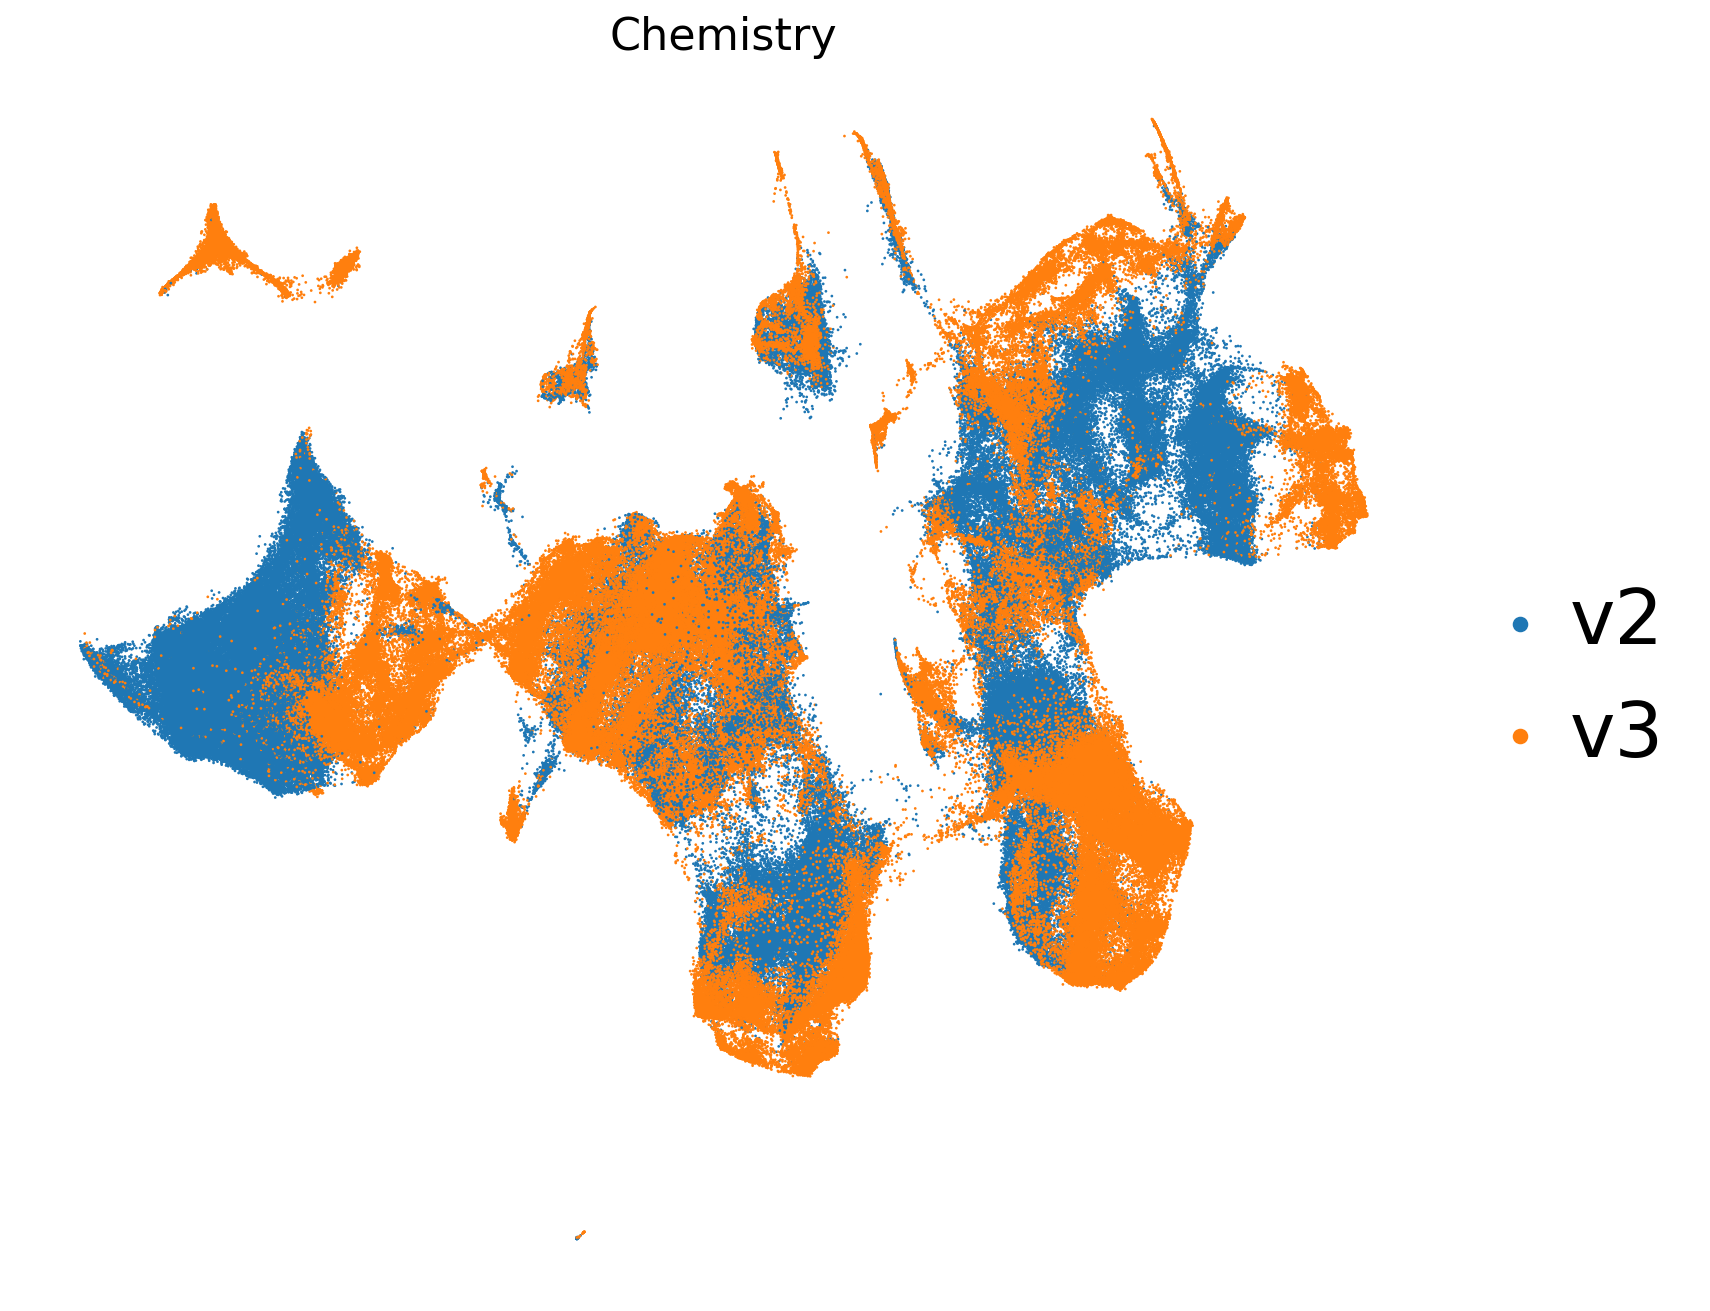

In [58]:
sc.pl.umap(adata_RG_all_gt5,legend_fontsize = 'xx-large', color = 'Chemistry',frameon=False, size=6, vmax=2, sort_order =False, save = 'Chemistry_umap.svg')


/home/labs/reinerlab/miridan/.conda/envs/symphony2/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


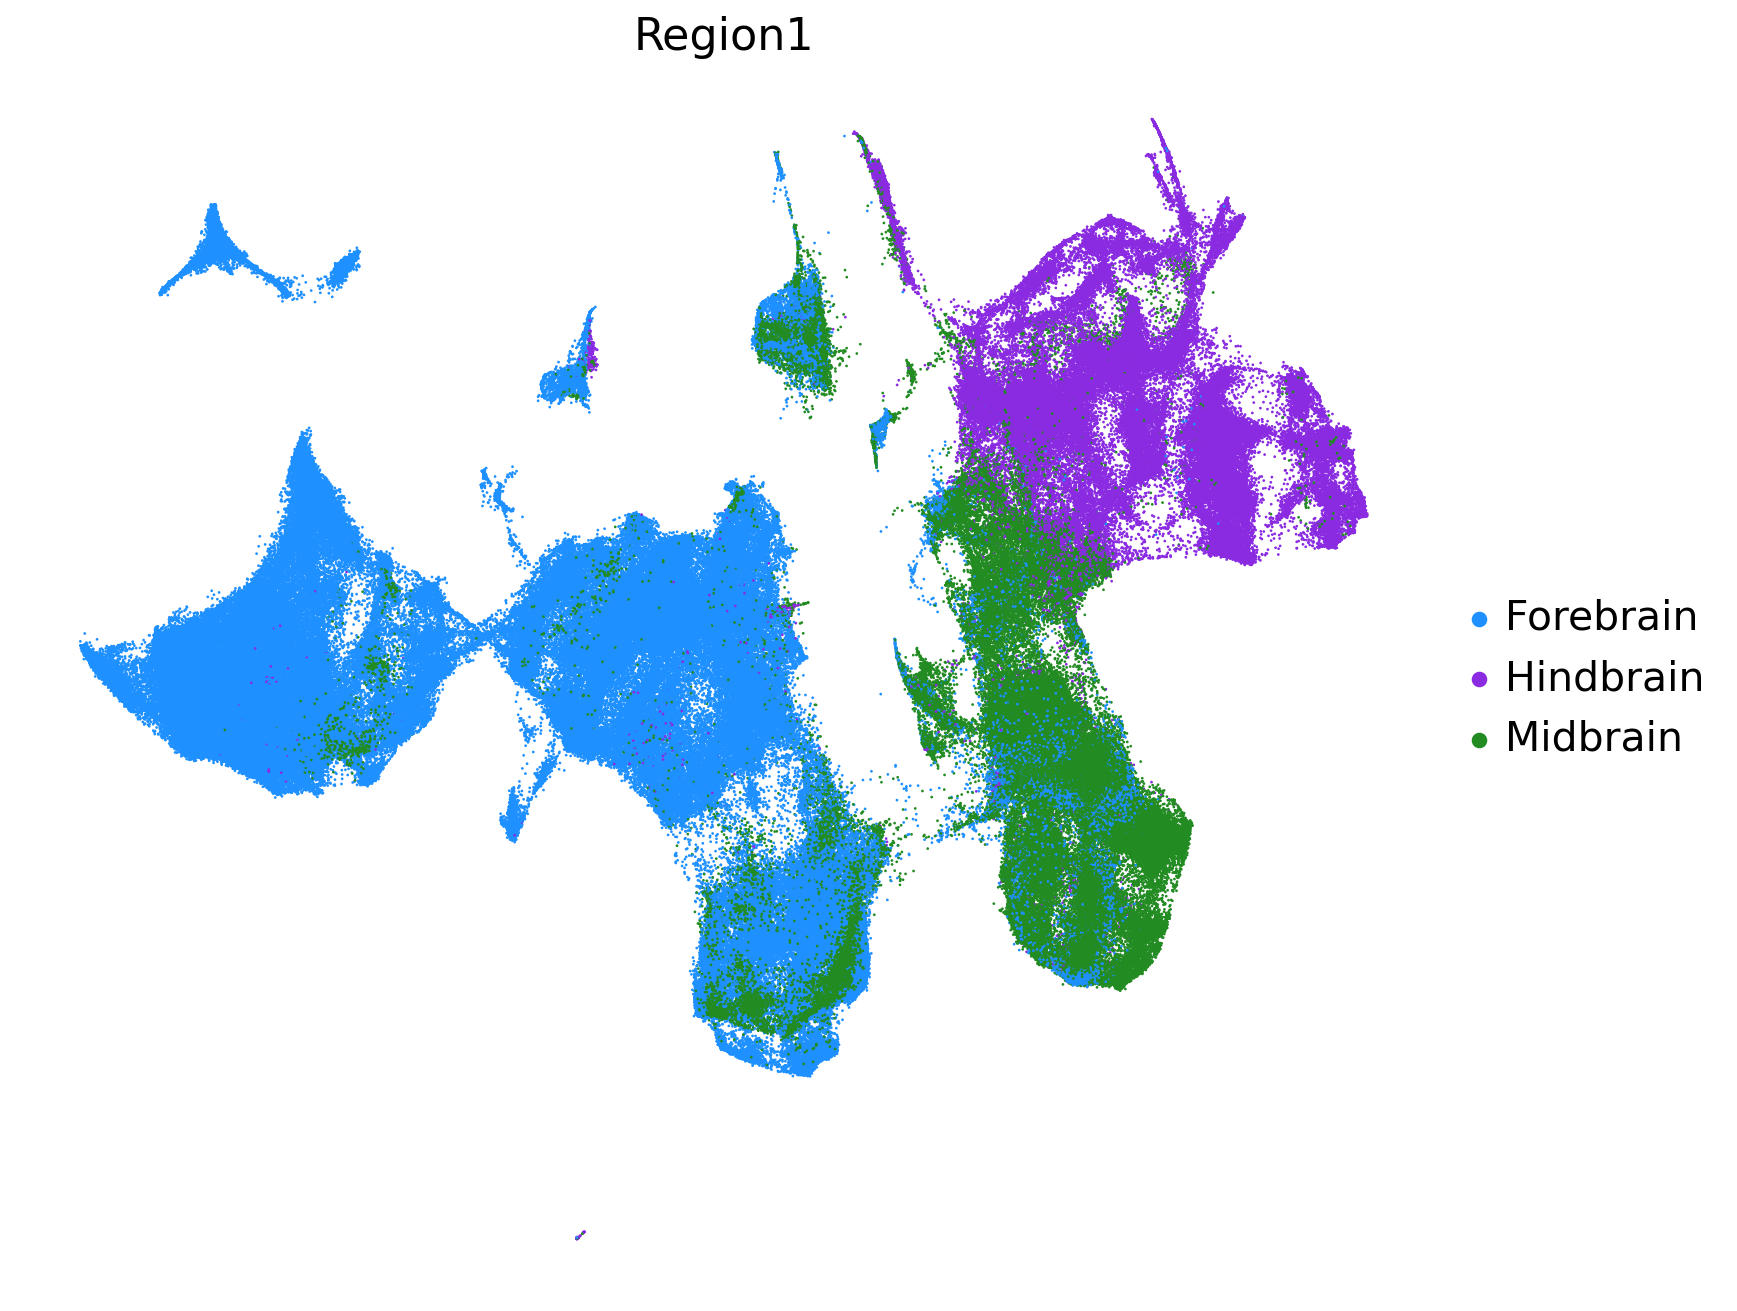

In [57]:
sc.pl.umap(adata_RG_all_gt5,color = 'Region1',frameon=False, size=6, vmax=2, sort_order = False, palette={         "Forebrain": "dodgerblue",   "Midbrain": "forestgreen",   "Hindbrain": "blueviolet"        }, save = 'Regions1_umap.svg')


/home/labs/reinerlab/miridan/.conda/envs/symphony2/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


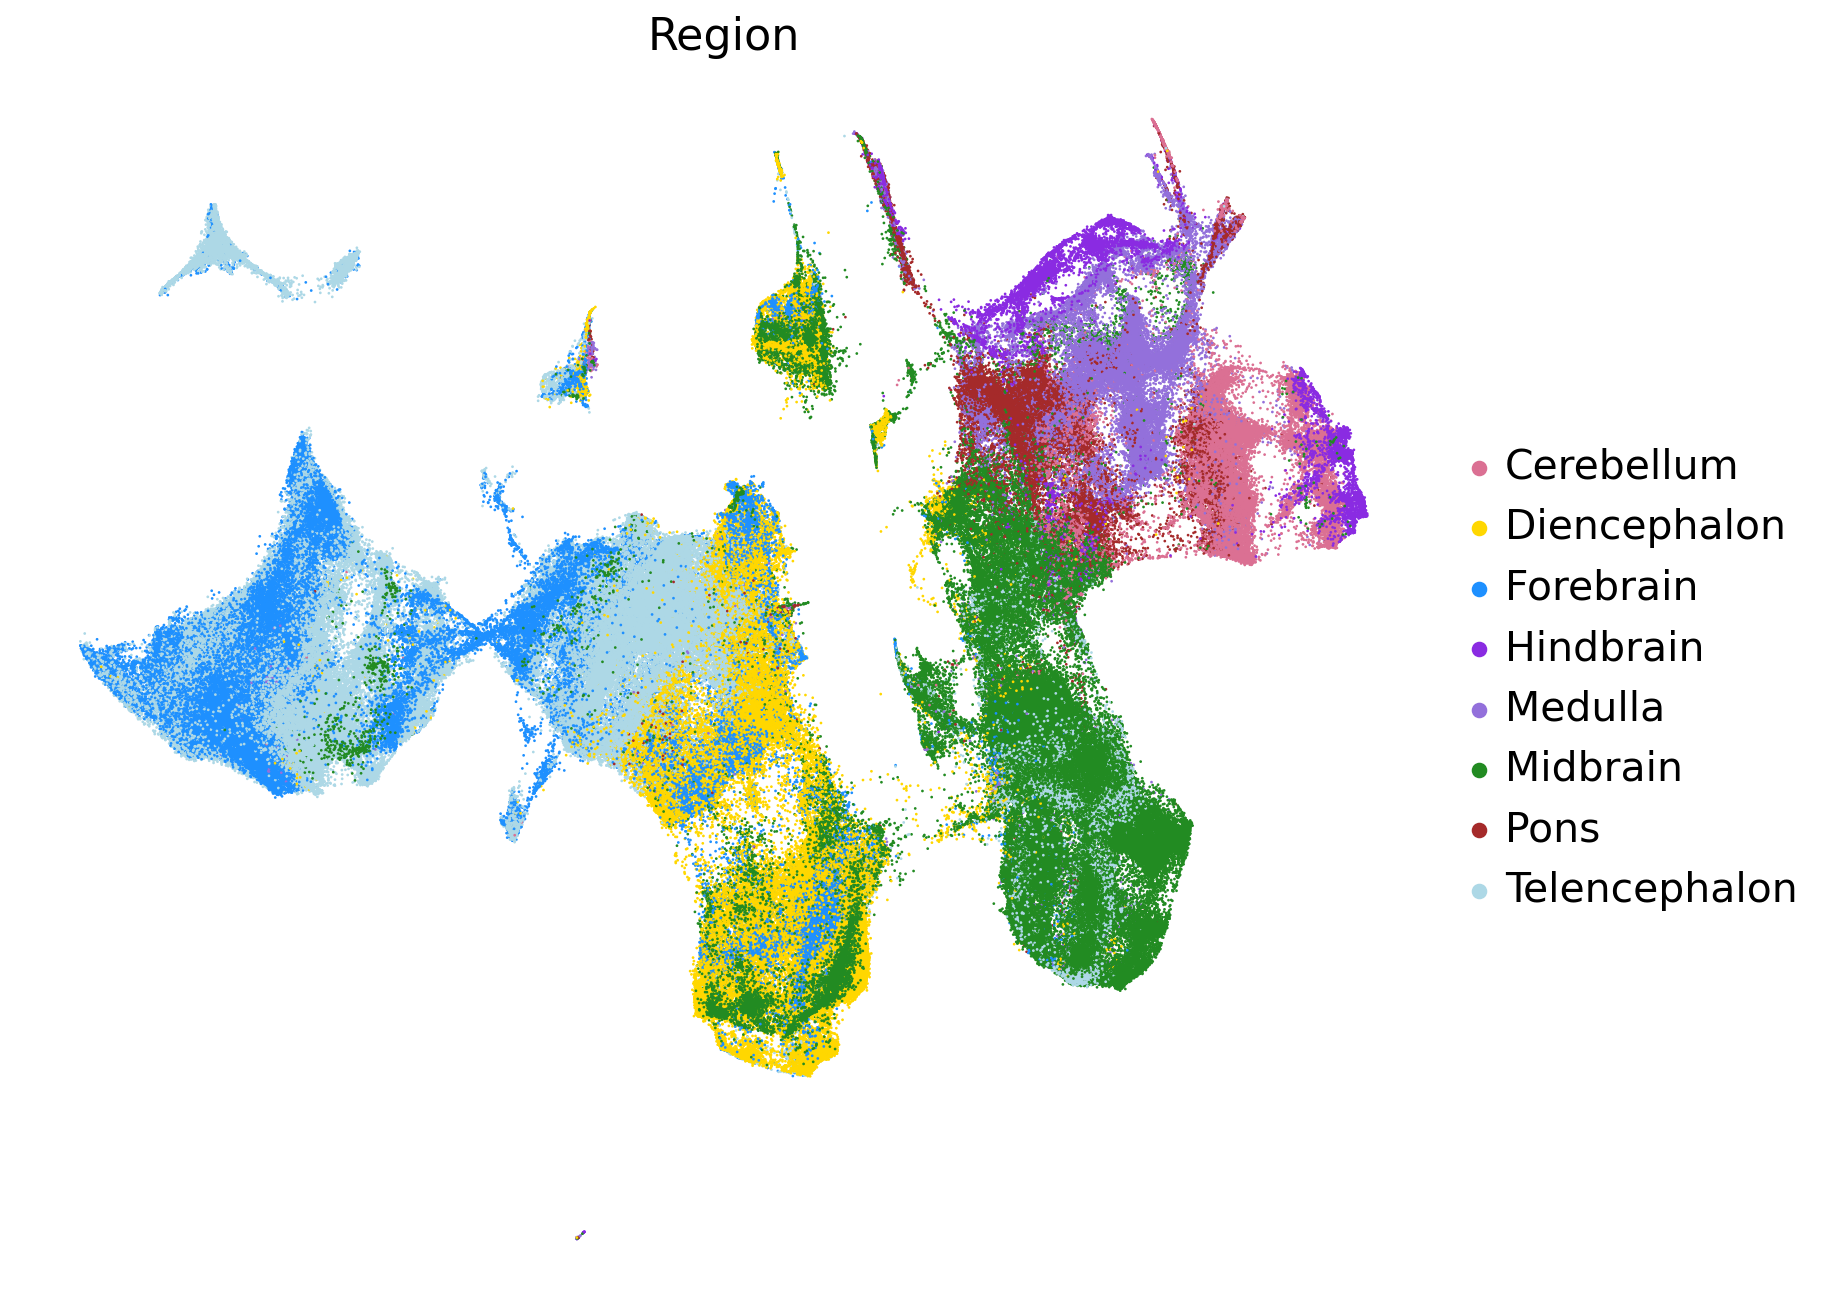

In [55]:
sc.pl.umap(adata_RG_all_gt5,color = 'Region',size=6, vmax=2, sort_order = False, palette={         "Forebrain": "dodgerblue", "Telencephalon": "lightblue",  "Diencephalon": "gold" ,      "Midbrain": "forestgreen",   "Cerebellum":"palevioletred",      "Hindbrain": "blueviolet","Pons":"brown", "Medulla": "mediumpurple"          },frameon=False,save = 'Regions_umap.svg' )


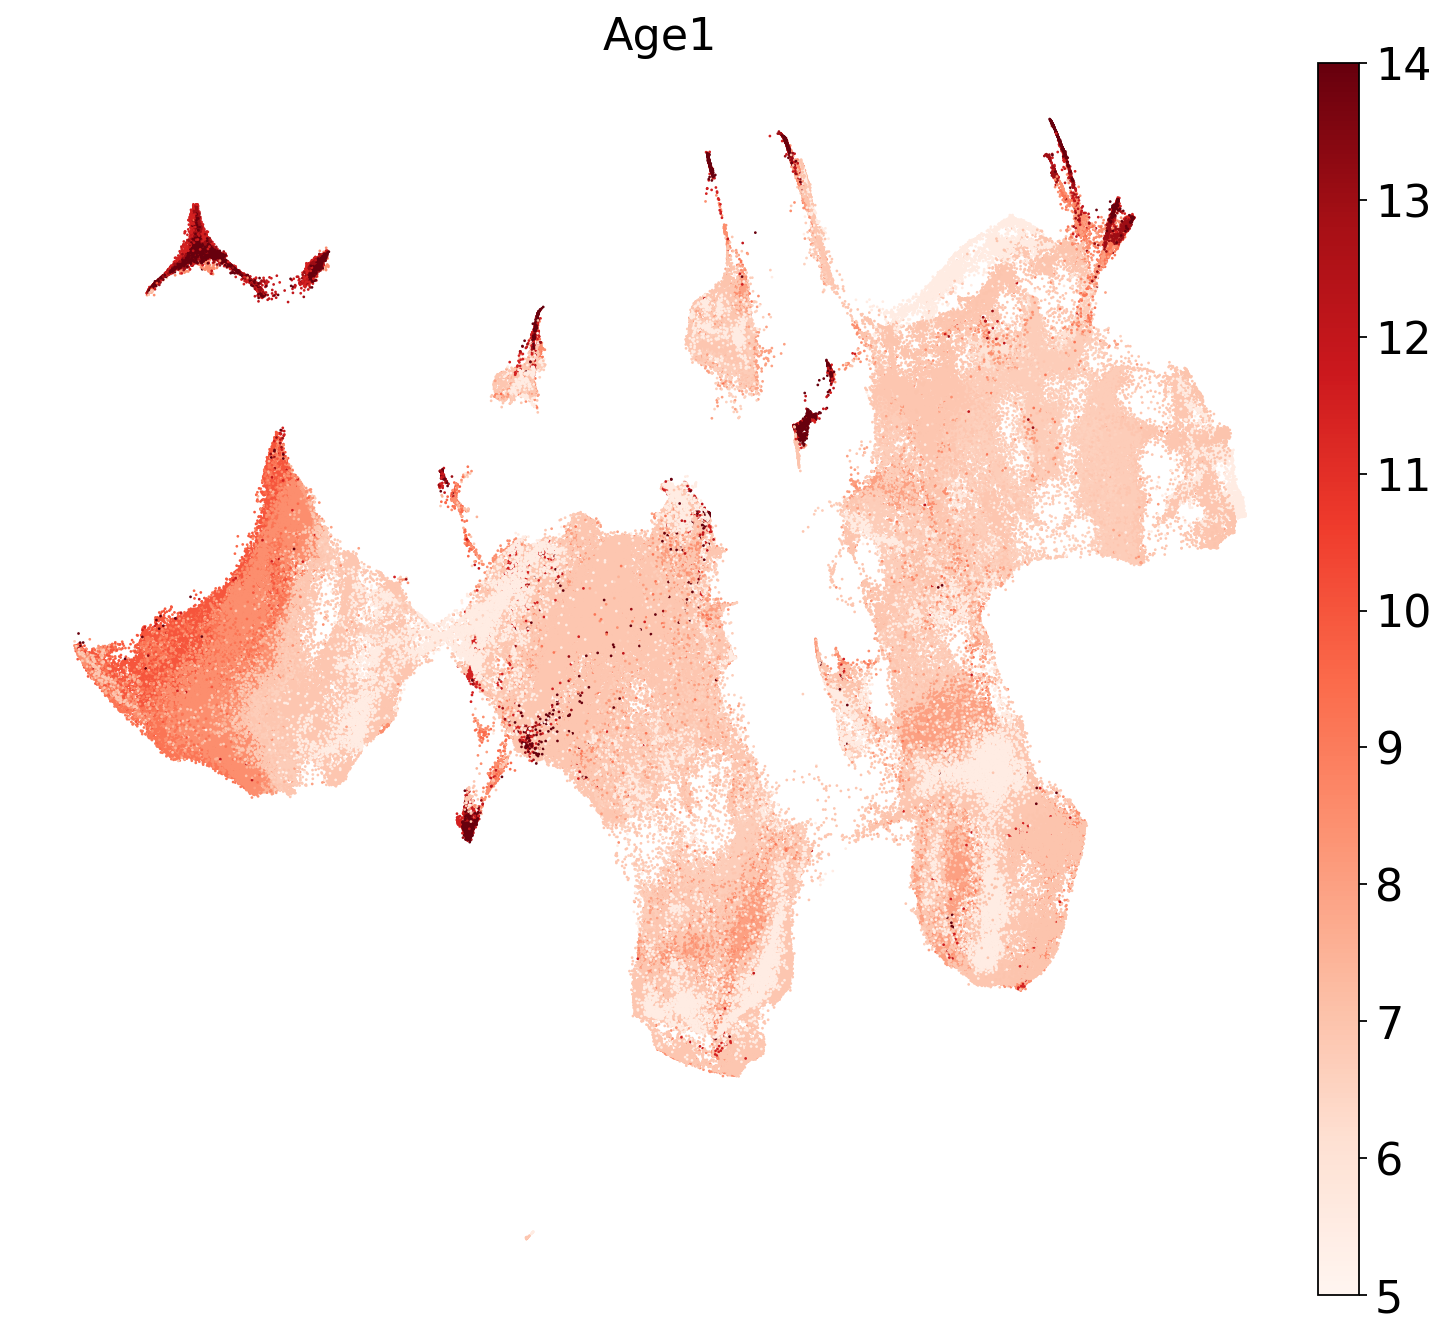

In [59]:
adata_RG_all_gt5.obs['Age1'] = adata_RG_all_gt5.obs['Age'].astype(float)
reds = copy(mpl.cm.Reds)
sc.pl.umap(adata_RG_all_gt5,color = 'Age1',size=6 ,cmap=reds, vmin=5, sort_order = False,save = 'Age_umap.svg')

In [5]:
#adata_RG_all = sc.read("/home/labs/reinerlab/miridan/human_development_adata/ClassRadialGlia_for_harmony_symp2.h5ad")

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [4]:
adata_NDE1 = sc.read('/home/labs/reinerlab/Collaboration/Tamar_scRNA_NDE_jan23/analysis/seurat.analysis_30Jan23_25PCA_res0.6.h5ad')

Only considering the two last: ['.6', '.h5ad'].
Only considering the two last: ['.6', '.h5ad'].


/home/labs/reinerlab/miridan/.conda/envs/symphony2/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/home/labs/reinerlab/miridan/.conda/envs/symphony2/lib/python3.9/site-packages/anndata/compat/__init__.py:298: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


In [22]:
del adata_NDE1.raw

In [5]:
import anndata as ad
adata_NDE1_raw = ad.AnnData(adata_NDE1.raw.X.copy())
adata_NDE1_raw.var_names = adata_NDE1.raw.var['_index']


In [105]:
adata_NDE1

AnnData object with n_obs × n_vars = 7889 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'corrected.ident', 'genotypes', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.6', 'seurat_clusters', 'cluster.genotype', 'clusters_30PCA_res0.5', 'new.cluster.name', 'clusters25PCA_res0.6', 'SCT_snn_res.1.2', 'clusters25PCA_res1.2', 'SCT_snn_res.1.4', 'clusters25PCA_res1.4'
    var: 'features'
    uns: 'neighbors'
    obsm: 'X_pca', 'X_umap', 'X_pca_reference', 'X_pca_harmony', 'X_pca_harmony_symphony_R'
    varm: 'PCs'
    obsp: 'distances'

In [6]:
adata_NDE1_raw.obs= adata_NDE1.obs

In [48]:
adata_NDE1_raw.var_names

Index(['AL627309.1', 'AL627309.5', 'LINC01409', 'LINC01128', 'LINC00115',
       'FAM41C', 'AL645608.6', 'AL645608.2', 'LINC02593', 'SAMD11',
       ...
       'AC092338.1', 'NPIPB15', 'AC126696.3', 'AC104564.5', 'ABCA6',
       'AC087645.2', 'KCNA7', 'AC000068.2', 'LGALS2', 'AL672277.1'],
      dtype='object', name='_index', length=23598)

In [7]:

sc.pp.normalize_total(adata_NDE1_raw, target_sum=1e5)
sc.pp.log1p(adata_NDE1_raw)
adata_NDE1_raw.var_names_make_unique()

In [1]:

adata_NDE1_raw.write("/home/labs/reinerlab/miridan/NDE1/NDE1_seurat_raw.analysis_30Jan23_25PCA_res06.h5ad")

NameError: name 'adata_NDE1_raw' is not defined

In [8]:
adata_RG_all_gt5.obs['AgeStr'] = np.floor(adata_RG_all_gt5.obs['Age'].astype('int')).astype('str')

In [9]:
adata_RG_all_gt5.obs['cond'] = 'RG'


In [31]:
adata_NDE1.raw.var

,_index
0,AL627309.1
1,AL627309.5
2,LINC01409
3,LINC01128
4,LINC00115
...,...
23593,AC087645.2
23594,KCNA7
23595,AC000068.2
23596,LGALS2


In [13]:
sp.tl.map_embedding(adata_NDE1_raw, adata_RG_all_gt5)

77 out of 1053 genes from the reference are missing in the query dataset or have zero std in the reference, their expressions in the query will be set to zero


In [14]:
sp.tl.per_cell_confidence(adata_NDE1_raw, adata_RG_all_gt5)
# -> adata_query.obs["symphony_per_cell_dist"] <- Symphony mapping score per cell
#sp.tl.per_cluster_confidence(adata_NDE1, adata_RG_all, query_clusters)
# -> adata_query.uns["symphony_per_cluster_dist"] <- Symphony mapping score per cluster

ValueError: operands could not be broadcast together with shapes (100,1,477251) (30,449645) 

In [16]:
sp.tl.ingest(adata_NDE1_raw, adata_RG_all_gt5, use_rep="X_pca_harmony")

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/symphonypy/_utils.py:372: UserWarning: 'X_pca' adata_reference's representation was used for reference, while 'X_pca_harmony' was used for query. Be sure that they correspond.
  warnings.warn(


In [20]:
sp.tl.transfer_labels_kNN(
    adata_query=adata_NDE1_raw,
    adata_ref=adata_RG_all_gt5,
    ref_labels=["AgeStr", "Subregion","Region","Region1","CellClass"])

In [23]:
adata_NDE1.write("/home/labs/reinerlab/miridan/NDE1/NDE1_seurat.analysis_30Jan23_25PCA_res06_RG_all_gt5_symp.h5ad")

In [4]:
adata_NDE1 = sc.read("/home/labs/reinerlab/miridan/NDE1/NDE1_seurat.analysis_30Jan23_25PCA_res06_RG_all_gt5_symp.h5ad")

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [9]:
adata_RG_all.obs.Region1 = adata_RG_all.obs.Region1.astype('str')

/home/labs/reinerlab/miridan/.conda/envs/symphony2/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(
/home/labs/reinerlab/miridan/.conda/envs/symphony2/lib/python3.9/site-packages/scanpy/plotting/_utils.py:431: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/home/labs/reinerlab/miridan/.conda/envs/symphony2/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/labs/reinerlab/miridan/.conda/envs/symphony2/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(
/home/labs/reinerlab/miridan/

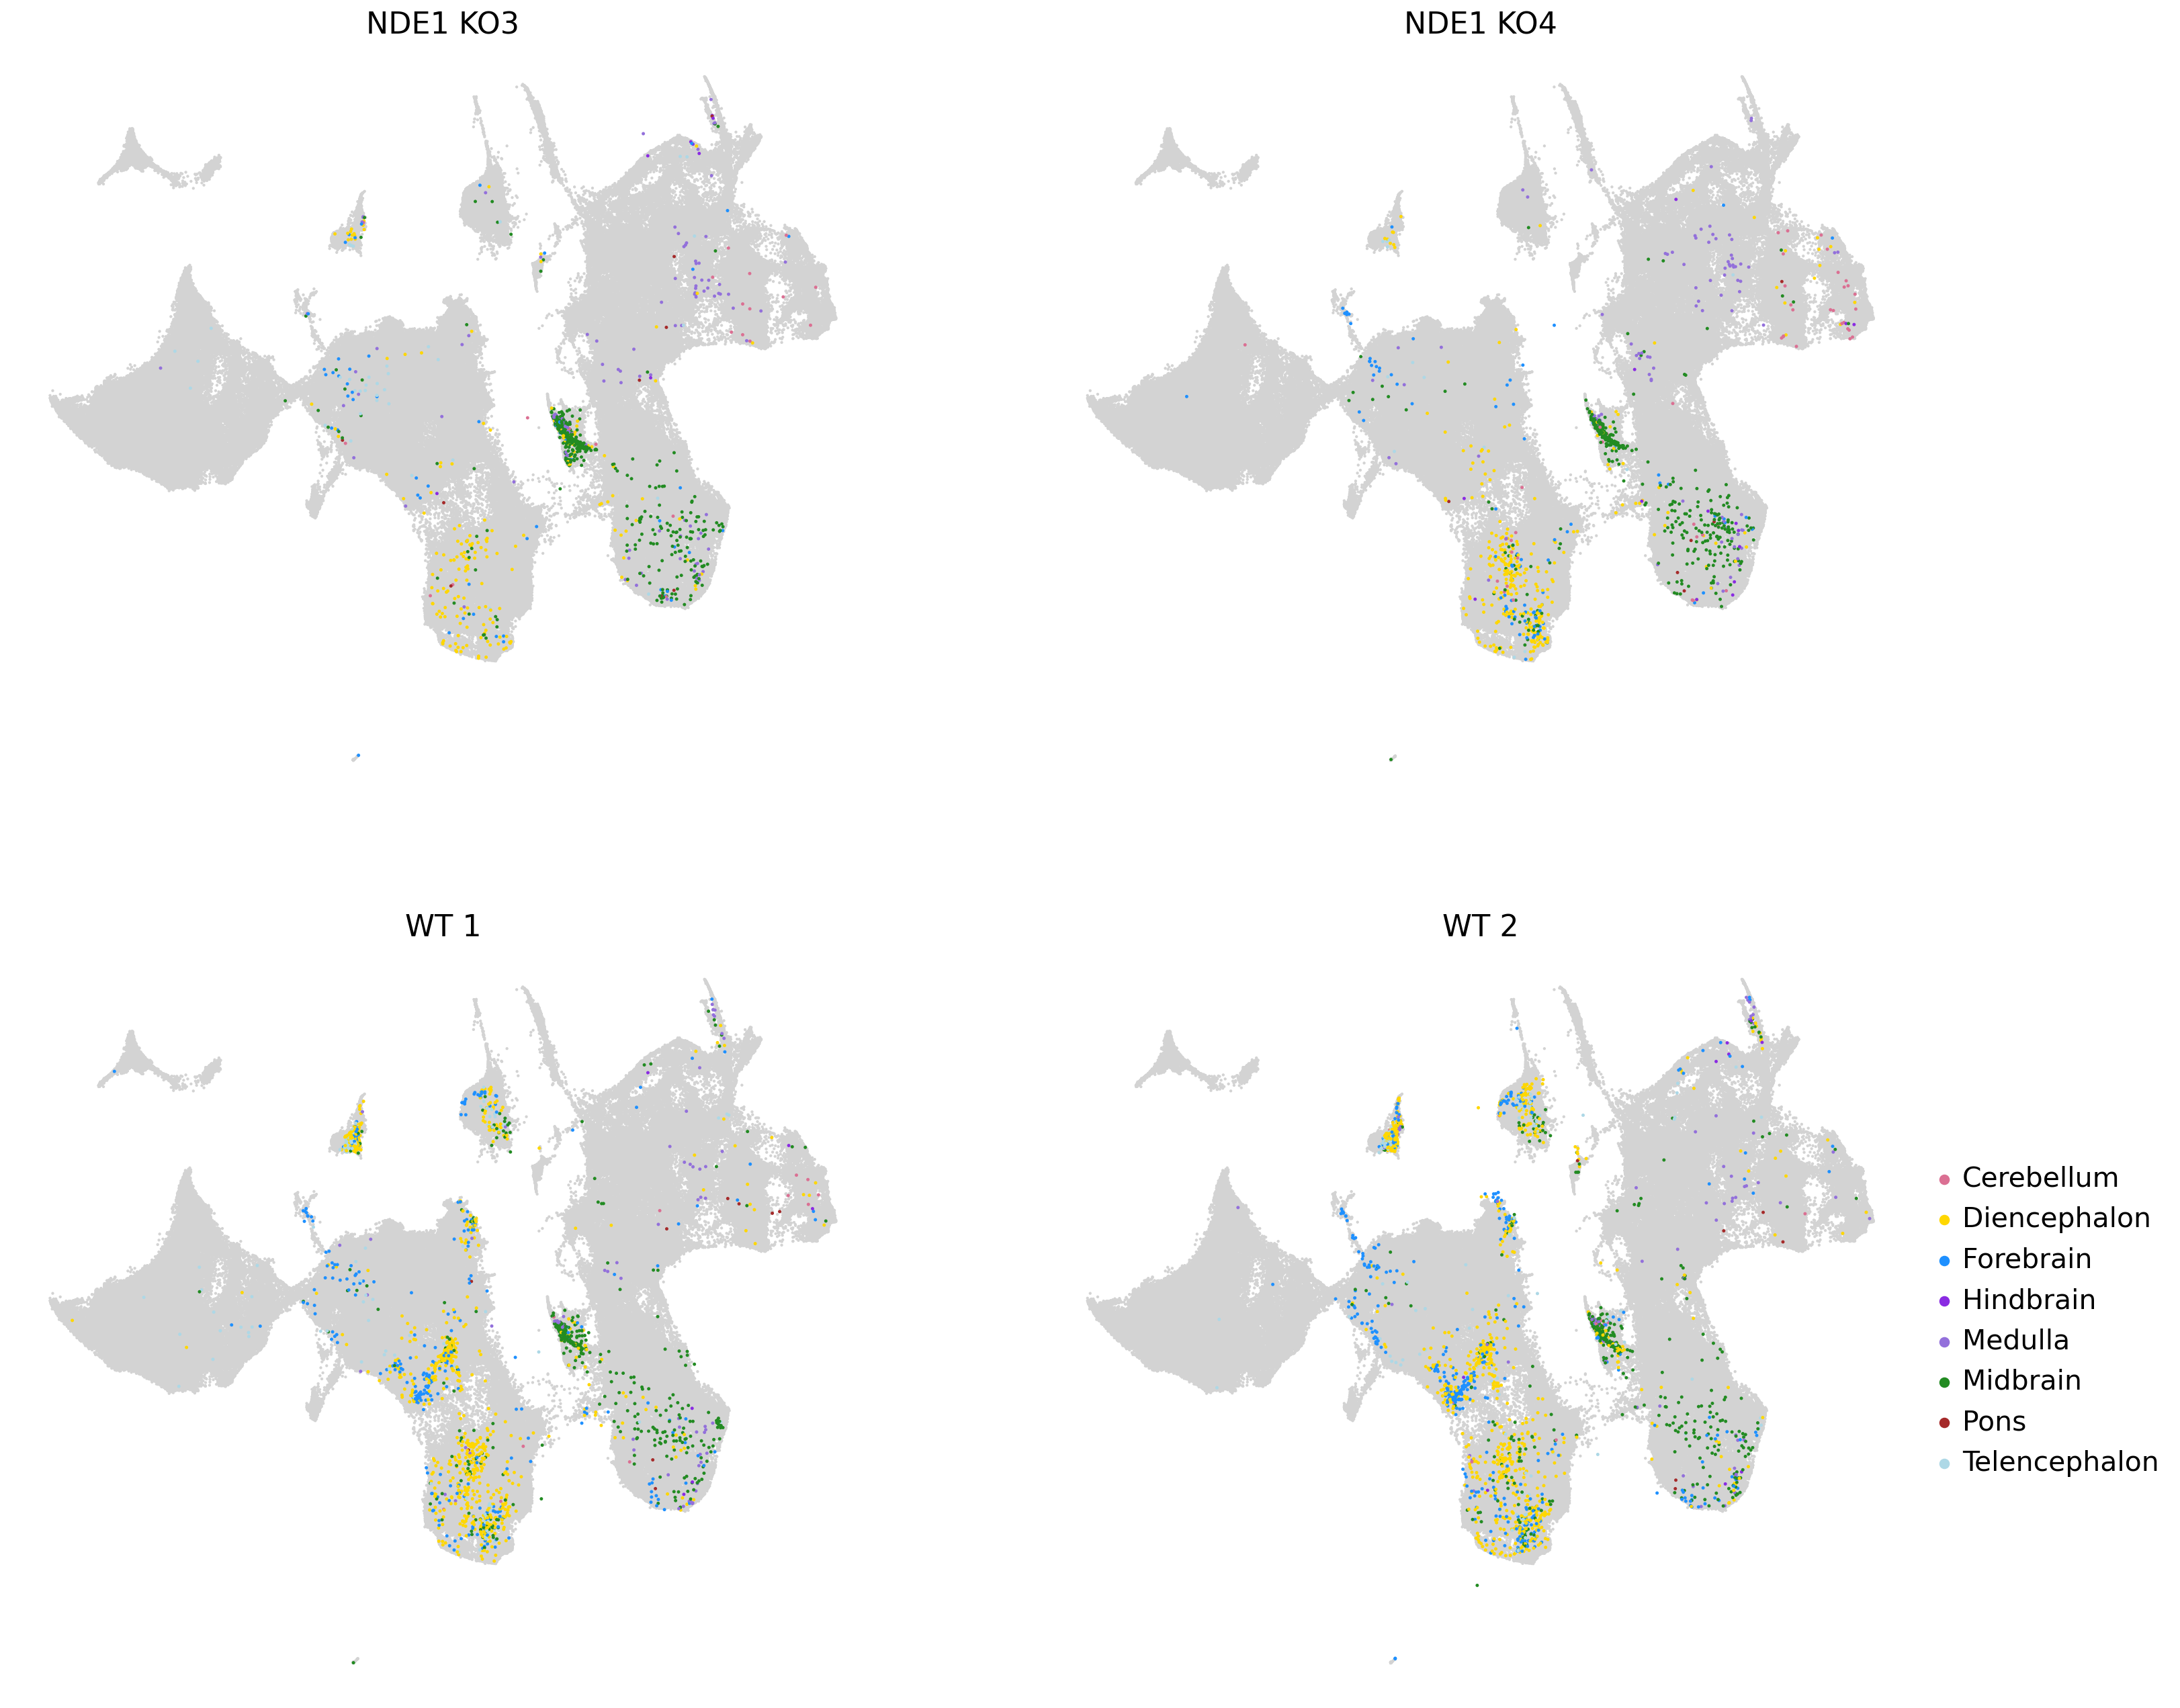

In [73]:
fig, axes = plt.subplots(figsize=(umap_w*2, umap_h*2), ncols=2, nrows = 2)
sc.pl.umap(
    adata_RG_all_gt5,
    frameon=False,
    ax=axes[1,0],
    show=False,size=15,legend_loc=None,palette={          "Forebrain": "dodgerblue",   "Midbrain": "forestgreen",   "Hindbrain": "blueviolet"           }
    
)
sc.pl.umap(
    adata_NDE1_raw[adata_NDE1_raw.obs['corrected.ident']=='W3_ep3',:],
    color="Region",
    frameon=False,
    title="WT 1",
    ax=axes[1,0],
    show=False,size=20,legend_loc=None,palette={        "Forebrain": "dodgerblue", "Telencephalon": "lightblue",  "Diencephalon": "gold" ,      "Midbrain": "forestgreen",   "Cerebellum":"palevioletred",      "Hindbrain": "blueviolet","Pons":"brown", "Medulla": "mediumpurple"      },

)
sc.pl.umap(
    adata_RG_all_gt5,
    frameon=False,
    ax=axes[1,1],
    show=False,size=15,legend_loc=None,palette={        "Forebrain": "dodgerblue",   "Midbrain": "forestgreen",   "Hindbrain": "blueviolet"            }
    
)
sc.pl.umap(
    adata_NDE1_raw[adata_NDE1_raw.obs['corrected.ident']=='W3_e3',:],
    color="Region",
    frameon=False,
    title="WT 2",
    ax=axes[1,1],
    show=False,size=20,palette={         "Forebrain": "dodgerblue", "Telencephalon": "lightblue",  "Diencephalon": "gold" ,      "Midbrain": "forestgreen",   "Cerebellum":"palevioletred",      "Hindbrain": "blueviolet","Pons":"brown", "Medulla": "mediumpurple"          },

)

sc.pl.umap(
    adata_RG_all_gt5,
    frameon=False,
    ax=axes[0,0],
    show=False,size=15,legend_loc=None,palette={          "Forebrain": "dodgerblue",   "Midbrain": "forestgreen",   "Hindbrain": "blueviolet"           }
    
)
sc.pl.umap(
    adata_NDE1_raw[adata_NDE1_raw.obs['corrected.ident']=='KO_3',:],
    color="Region",
    frameon=False,
    title="NDE1 KO3",
    ax=axes[0,0],
    show=False,size=20,legend_loc=None,palette={       "Forebrain": "dodgerblue", "Telencephalon": "lightblue",  "Diencephalon": "gold" ,      "Midbrain": "forestgreen",   "Cerebellum":"palevioletred",      "Hindbrain": "blueviolet","Pons":"brown", "Medulla": "mediumpurple"            },
)
sc.pl.umap(
    adata_RG_all_gt5,
    frameon=False,
    ax=axes[0,1],
    show=False,size=15,legend_loc=None,palette={          "Forebrain": "dodgerblue",   "Midbrain": "forestgreen",   "Hindbrain": "blueviolet"           }
    
)
    

sc.pl.umap(
    adata_NDE1_raw[adata_NDE1_raw.obs['corrected.ident']=='KO_4',:],
    color="Region",
    frameon=False,
    title="NDE1 KO4",
    ax=axes[0,1],
    show=False,size=20,legend_loc=None,palette={         "Forebrain": "dodgerblue", "Telencephalon": "lightblue",  "Diencephalon": "gold" ,      "Midbrain": "forestgreen",   "Cerebellum":"palevioletred",      "Hindbrain": "blueviolet","Pons":"brown", "Medulla": "mediumpurple"         },

    
)
plt.savefig('/home/labs/reinerlab/miridan/NDE1/final_figs/NDE1_Region_gt5.pdf',dpi=200)

In [68]:
len(np.where(adata_NDE1[adata_NDE1.obs['corrected.ident']=='W3_e3',:].obs['Region']=="Midbrain")[0])

1094

In [26]:
#Calc ratio for each region

regions = np.unique(adata_NDE1_raw.obs['Region'])
reg_tab = pd.DataFrame(columns=regions, index = ['W3_e3','W3_ep3','KO_3','KO_4'])

for i,r in enumerate(regions): 
    reg_tab.iloc[0,i]=len(np.where(adata_NDE1_raw[adata_NDE1_raw.obs['corrected.ident']=='W3_e3',:].obs['Region']==r)[0])
    reg_tab.iloc[1,i]=len(np.where(adata_NDE1_raw[adata_NDE1_raw.obs['corrected.ident']=='W3_ep3',:].obs['Region']==r)[0])
    reg_tab.iloc[2,i]=len(np.where(adata_NDE1_raw[adata_NDE1_raw.obs['corrected.ident']=='KO_3',:].obs['Region']==r)[0])
    reg_tab.iloc[3,i]=len(np.where(adata_NDE1_raw[adata_NDE1_raw.obs['corrected.ident']=='KO_4',:].obs['Region']==r)[0])
                    

In [115]:
ind = np.where(adata_NDE1_raw.obs['Region']=="Telencephalon")[0]

In [27]:
reg_tab


,Cerebellum,Diencephalon,Forebrain,Hindbrain,Medulla,Midbrain,Pons,Telencephalon
W3_e3,14,1477,699,12,99,589,6,412
W3_ep3,13,1045,425,6,82,458,9,267
KO_3,23,206,78,8,152,737,9,37
KO_4,48,301,99,14,100,442,6,16


In [15]:
reg_tab


,Cerebellum,Diencephalon,Forebrain,Hindbrain,Medulla,Midbrain,Pons,Telencephalon
W3_e3,27,1496,675,21,140,413,3,533
W3_ep3,18,1014,472,15,112,301,10,363
KO_3,34,210,162,22,164,602,10,46
KO_4,34,246,245,22,128,309,6,36


In [16]:
np.sum(reg_tab,axis=1)

W3_e3     3308.0
W3_ep3    2305.0
KO_3      1250.0
KO_4      1026.0
dtype: float64

In [28]:
reg_tab_per = reg_tab.divide(np.sum(reg_tab,axis=1), axis=0)

In [29]:
reg_tab_per

,Cerebellum,Diencephalon,Forebrain,Hindbrain,Medulla,Midbrain,Pons,Telencephalon
W3_e3,0.004232,0.446493,0.211306,0.003628,0.029927,0.178053,0.001814,0.124547
W3_ep3,0.00564,0.453362,0.184382,0.002603,0.035575,0.198698,0.003905,0.115835
KO_3,0.0184,0.1648,0.0624,0.0064,0.1216,0.5896,0.0072,0.0296
KO_4,0.046784,0.293372,0.096491,0.013645,0.097466,0.430799,0.005848,0.015595


In [30]:
reg_per = reg_tab_per.melt()

In [66]:
reg_per['sample']= np.tile(['WT1','WT2','NDE1 KO3','NDE KO4'],8)

In [67]:
reg_per

,variable,value,sample
0,Cerebellum,0.004232,WT1
1,Cerebellum,0.00564,WT2
2,Cerebellum,0.0184,NDE1 KO3
3,Cerebellum,0.046784,NDE KO4
4,Diencephalon,0.446493,WT1
5,Diencephalon,0.453362,WT2
6,Diencephalon,0.1648,NDE1 KO3
7,Diencephalon,0.293372,NDE KO4
8,Forebrain,0.211306,WT1
9,Forebrain,0.184382,WT2


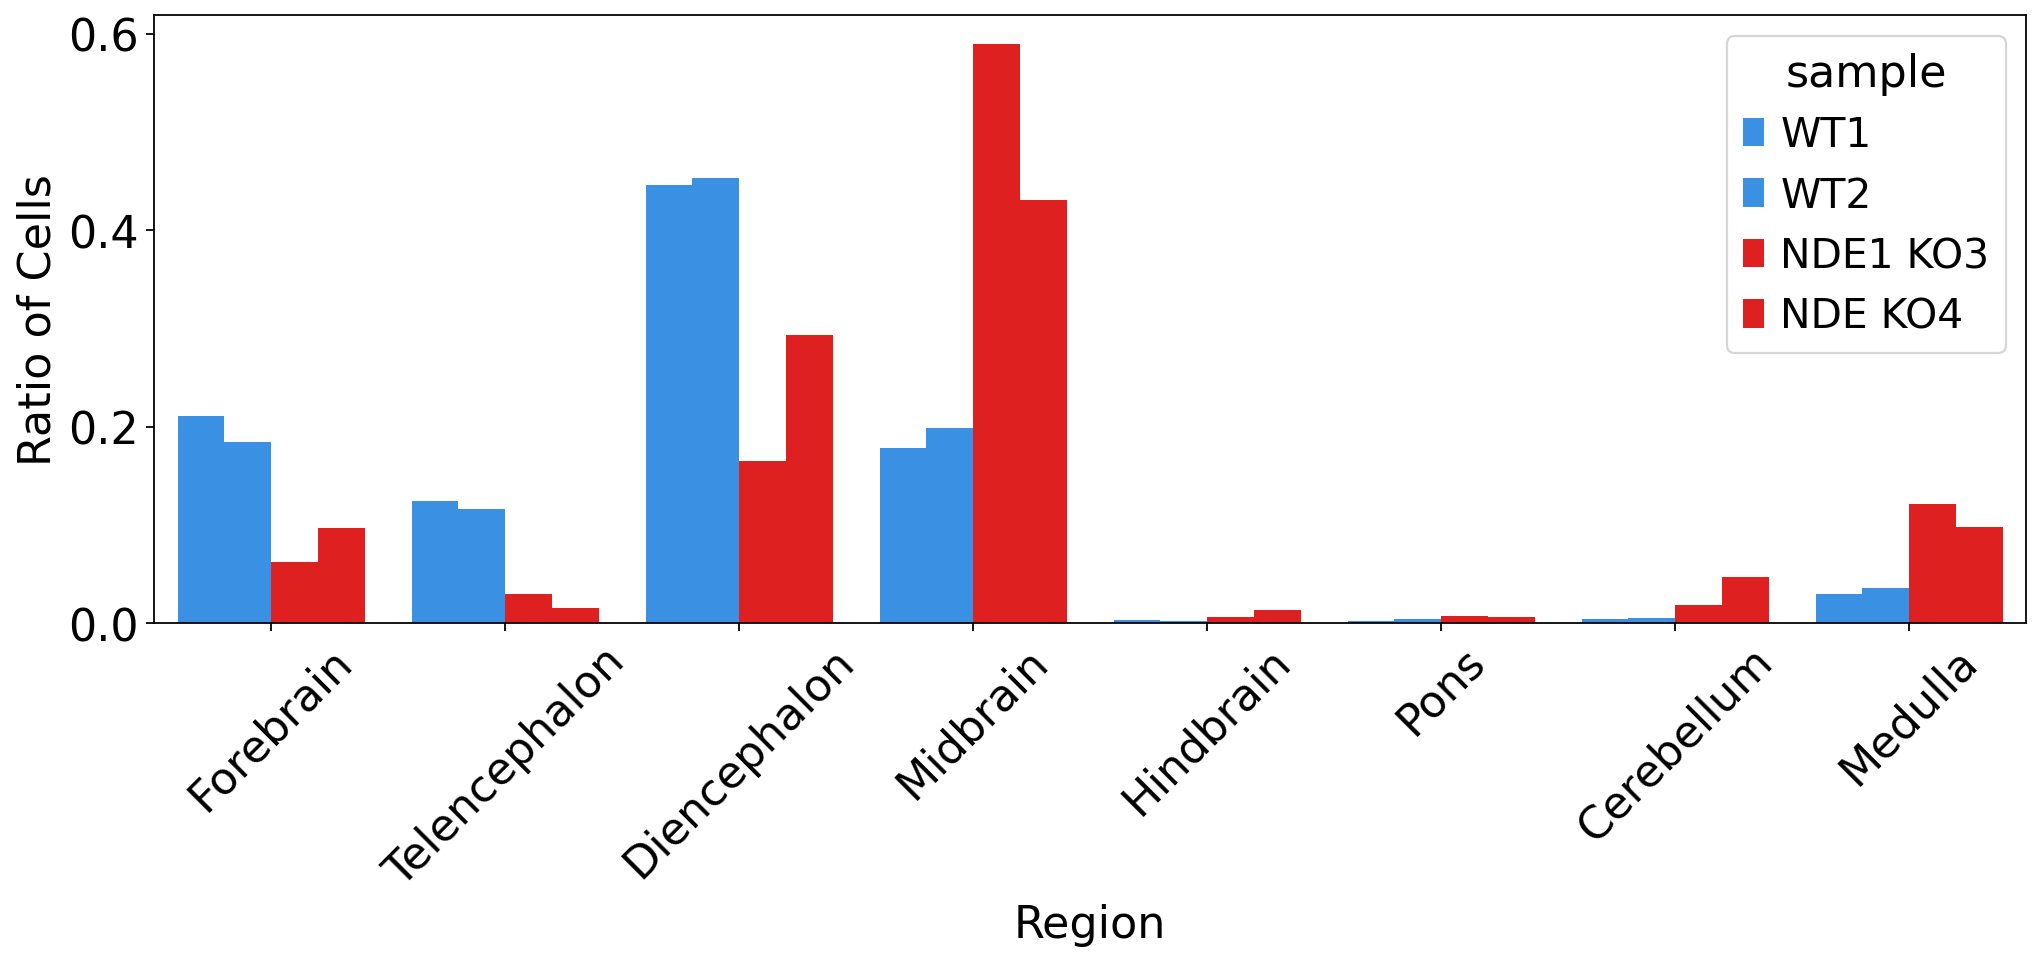

In [74]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.barplot(data= reg_per, x ='variable',y = 'value',hue = 'sample',order= ['Forebrain','Telencephalon', 'Diencephalon','Midbrain','Hindbrain','Pons','Cerebellum','Medulla'], palette=['dodgerblue','dodgerblue', 'red','red'])
plt.xticks(rotation=45)
ax.grid(False)
ax.set(xlabel='Region',
       ylabel='Ratio of Cells')
plt.savefig('/home/labs/reinerlab/miridan/NDE1/final_figs/NDE1_barplot_gt5.pdf',dpi=200)

In [72]:
from scipy.stats import fisher_exact
for i,c in enumerate(reg_tab.columns):

    tab = np.array([[np.sum(reg_tab.iloc[0:2,i]), np.sum(np.sum(reg_tab.iloc[0:2,:]))-np.sum(reg_tab.iloc[0:2,i])],[np.sum(reg_tab.iloc[2:4,i]),np.sum(np.sum(reg_tab.iloc[2:4,:]))-np.sum(reg_tab.iloc[2:4,i])]])
    res = fisher_exact(tab, alternative='two-sided')
    print(c," ",str(res))

Cerebellum   SignificanceResult(statistic=0.15011119347664936, pvalue=3.253640006696922e-19)
Diencephalon   SignificanceResult(statistic=2.8468589536205196, pvalue=2.6200690695024303e-82)
Forebrain   SignificanceResult(statistic=2.9693123051577426, pvalue=6.360937341169785e-45)
Hindbrain   SignificanceResult(statistic=0.3296124786741409, pvalue=0.0006307184663304657)
Medulla   SignificanceResult(statistic=0.2676262945040559, pvalue=3.352515534367306e-39)
Midbrain   SignificanceResult(statistic=0.2133553792329409, pvalue=3.741534409028336e-183)
Pons   SignificanceResult(statistic=0.4038942479456949, pvalue=0.014616170946167935)
Telencephalon   SignificanceResult(statistic=5.772104993460853, pvalue=1.3244887994144169e-51)


In [171]:
np.sum(np.sum(reg_tab.iloc[2:3,i]))

17

In [127]:
age_tab

,10.0,11.0,12.0,13.0,14.0,5.0,6.0,7.0,8.0,9.0
W3_e3,1,132,60,0,13,196,2339,27,538,2
W3_ep3,2,78,49,0,10,138,1595,28,403,2
KO_3,2,14,2,2,13,57,1032,19,108,1
KO_4,2,14,1,0,2,103,751,24,128,1


In [2]:
adata_pallium= sc.read('/home/labs/reinerlab/miridan/human_development_adata/Cortex_EMX1_louvain3_passedQC_PostM_rev1.h5ad')

/home/labs/reinerlab/miridan/.local/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


/tmp/ipykernel_235452/1156019383.py:25: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(xy[:, 0], xy[:, 1], c="lightgrey",s = 1,   cmap=cmap)


<Figure size 432x288 with 0 Axes>

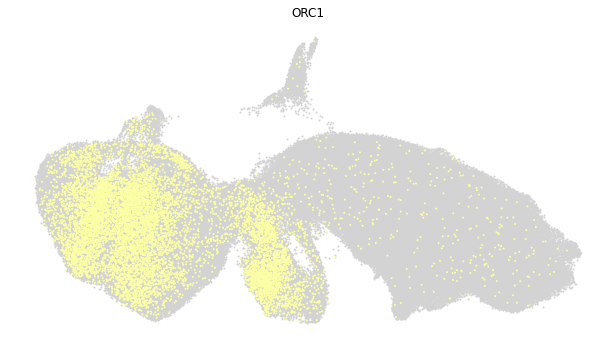

<Figure size 432x288 with 0 Axes>

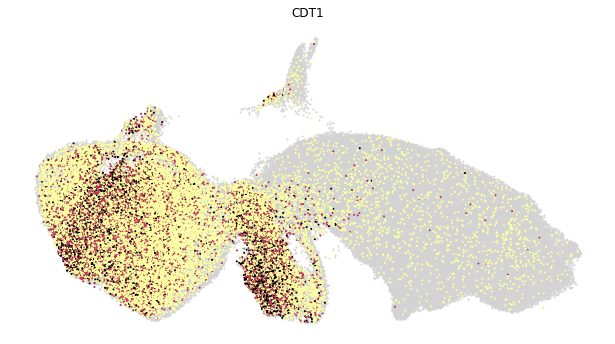

<Figure size 432x288 with 0 Axes>

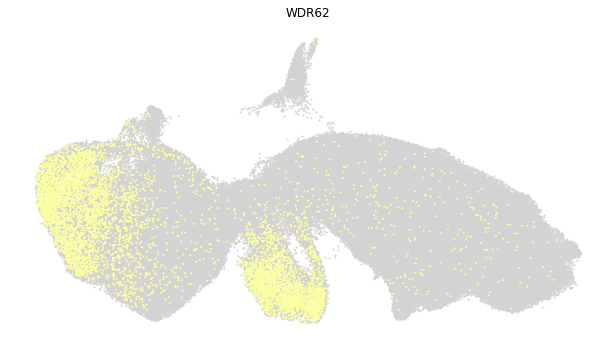

<Figure size 432x288 with 0 Axes>

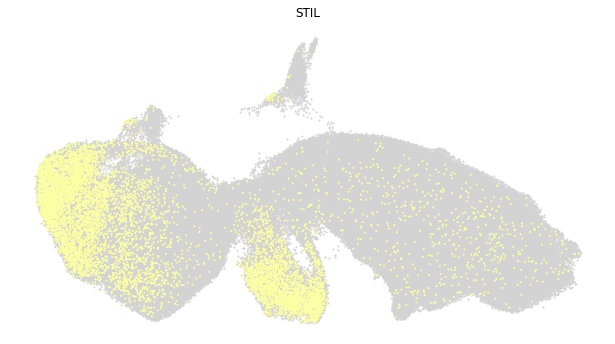

<Figure size 432x288 with 0 Axes>

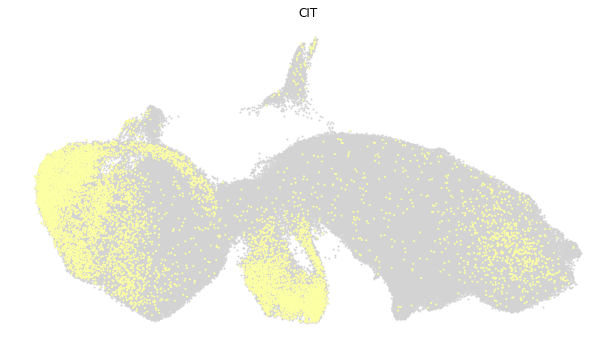

<Figure size 432x288 with 0 Axes>

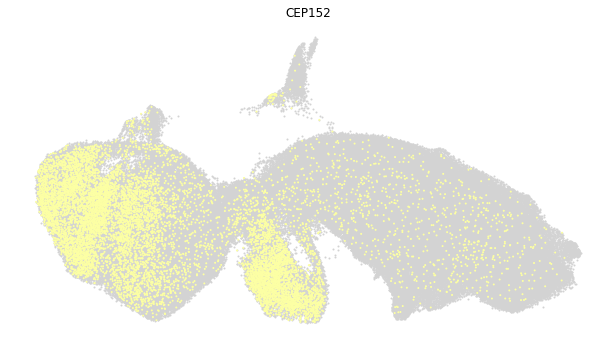

<Figure size 432x288 with 0 Axes>

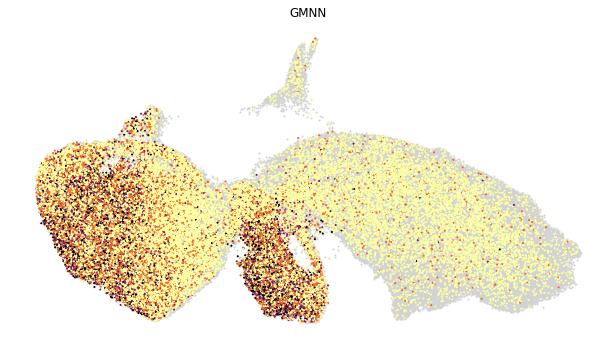

<Figure size 432x288 with 0 Axes>

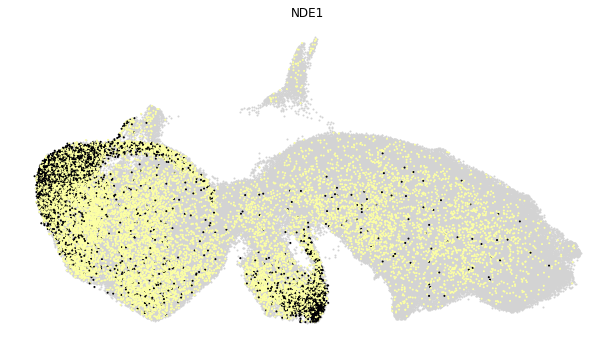

In [96]:
def cyt_scattern(anndata,gene,  max_percentile = 99, cmap = "inferno_r", bgval = 0):
    xy = anndata.obsm['X_umap'][:]
    c = anndata[:,np.where(adata_pallium.var_names==gene)[0]].X.toarray().flatten()
    
    n_cells = xy.shape[0]
    fig = plt.gcf()
    area = np.prod(fig.get_size_inches())
    marker_size = 100_000 / n_cells * (area / 25)
   
    plt.figure(figsize=((np.max(xy[:,0])+np.abs(np.min(xy[:,0])))/3, (np.max(xy[:,1])+np.abs(np.min(xy[:,1])))/3)) 

    if max_percentile < 100:
        max_val = np.percentile(c, max_percentile)
        assert np.all(max_val > 0), f"{max_percentile}th percentile is zero (increase max_percentile to fix)"
        c = np.clip(c, 0, max_val)

    ordering = np.random.permutation(xy.shape[0])
    color = c[ordering]
    xy = xy[ordering, :]
     #   s = kwargs.pop("s", marker_size)
     #   lw = kwargs.pop("lw", 0)
        
    if bgval is not None:
        cells = color != bgval
        plt.scatter(xy[:, 0], xy[:, 1], c="lightgrey",s = 1,   cmap=cmap)
        plt.scatter(xy[cells, 0], xy[cells, 1], c=color[cells],s = 1,  cmap=cmap)
    else:
        plt.scatter(xy[:, 0], xy[:, 1], c=color,s =1,  cmap=cmap)
    plt.title(gene)
    ax = plt.gca()  # Get the current axis
    ax.axis('off')
    plt.show()
   # if g is not None:
   #     ax = plt.gca()
   #     draw_edges(ax, xy, g, gcolor, galpha, glinewidths)




#genes = ['WDR62','STIL','CIT','CEP152']
genes = ['ORC1','CDT1','WDR62','STIL','CIT','CEP152','GMNN','NDE1']
for i in genes:
   # obs = adata_pallium[:,np.where(adata_pallium.var_names==i)[0]].X.toarray()
   # per = np.percentile(obs,99)
#sc.pl.umap(
#    adata_pallium,
#    color="SOX2",vmax = per, vmin=0,
#    cmap=sns.blend_palette(["lightgray", sns.xkcd_rgb["blood"]], as_cmap=True,) ,size = 0.7)
   # sc.pl.umap(
   #    adata_pallium,
   #    color=i,vmax = per, vmin=0.0001,
   #     cmap=reds,size = 1)
    cyt_scattern(anndata = adata_pallium, gene = i )


In [1]:

from scipy.stats import hypergeom
from copy import copy
mpl.rc('pdf', fonttype=42)
#from statannot import add_stat_annotation
from statannotations.Annotator import Annotator

In [2]:
adata_RG_all= sc.read('/miridan-storage/miridan/wexac_backup/human_development_adata/ClassRadialGlia_for_harmony.h5ad' , backed="r")

In [3]:
adata_RG_all_gt5 = adata_RG_all[adata_RG_all.obs['Age']!=5,:].to_memory()

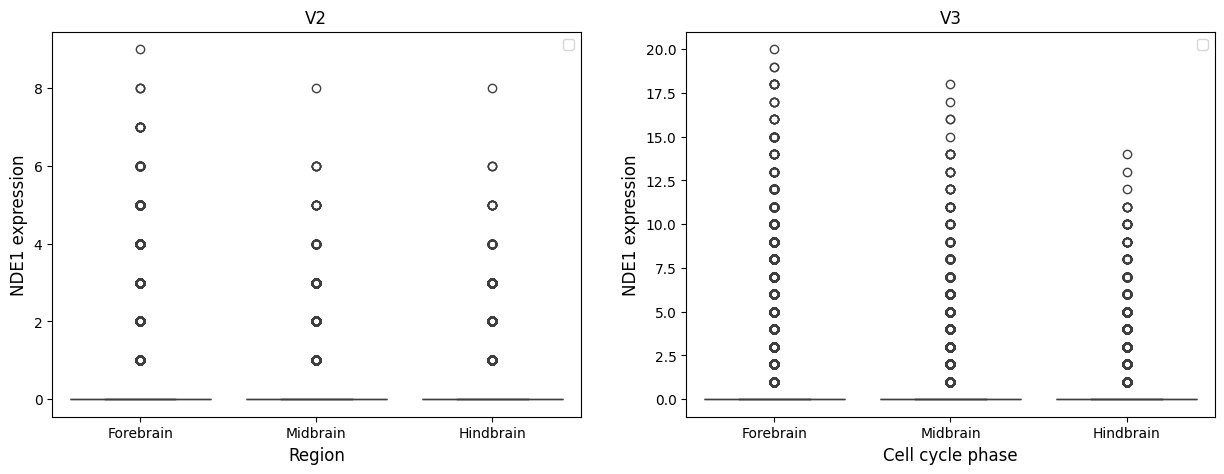

In [6]:
adata_RG_all_gt5_V2 = adata_RG_all_gt5[np.where(adata_RG_all_gt5.obs['Chemistry']=='v2')[0],:].copy()
adata_RG_all_gt5_V3 = adata_RG_all_gt5[np.where(adata_RG_all_gt5.obs['Chemistry']=='v3')[0],:].copy()
adata_RG_all_gt5_V2.obs['NDE1'] =  adata_RG_all_gt5_V2.layers['counts'][:,adata_RG_all_gt5_V2.var_names=='ENSG00000072864'].toarray().flatten()
adata_RG_all_gt5_V3.obs['NDE1'] =  adata_RG_all_gt5_V3.layers['counts'][:,adata_RG_all_gt5_V3.var_names=='ENSG00000072864'].toarray().flatten()
fig, axs = plt.subplots(1,2,figsize=(15, 5))
ax = sns.boxplot(ax = axs[0],x='Region1', y='NDE1',order= ['Forebrain','Midbrain','Hindbrain'] ,data=adata_RG_all_gt5_V2.obs)
axs[0].set_xlabel("Region", fontsize= 12)
axs[0].set_ylabel("NDE1 expression", fontsize= 12)
axs[0].set_title("V2", fontsize= 12)
axs[0].grid(False)
axs[0].legend('') 
ax = sns.boxplot(ax = axs[1],x='Region1', y='NDE1',order= ['Forebrain','Midbrain','Hindbrain'] ,data=adata_RG_all_gt5_V3.obs)
axs[1].set_xlabel("Region", fontsize= 12)
axs[1].set_ylabel("NDE1 expression", fontsize= 12)
axs[1].set_title("V3", fontsize= 12)
axs[1].grid(False)
axs[1].legend('') 

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Hindbrain vs. Midbrain: Mann-Whitney-Wilcoxon test two-sided, P_val:5.160e-01 U_stat=1.164e+07
Forebrain vs. Hindbrain: Mann-Whitney-Wilcoxon test two-sided, P_val:4.265e-45 U_stat=5.755e+07
Forebrain vs. Midbrain: Mann-Whitney-Wilcoxon test two-sided, P_val:5.258e-32 U_stat=4.300e+07
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Hindbrain vs. Midbrain: Mann-Whitney-Wilcoxon test two-sided, P_val:6.366e-02 U_stat=3.929e+07
Forebrain vs. Hindbrain: Mann-Whitney-Wilcoxon test two-sided, P_val:9.218e-09 U_stat=8.964e+07
Forebrain vs. Midbrain: Mann-Whitney-Wilcoxon test two-sided, P_val:1.036e-20 U_stat=1.521e+08


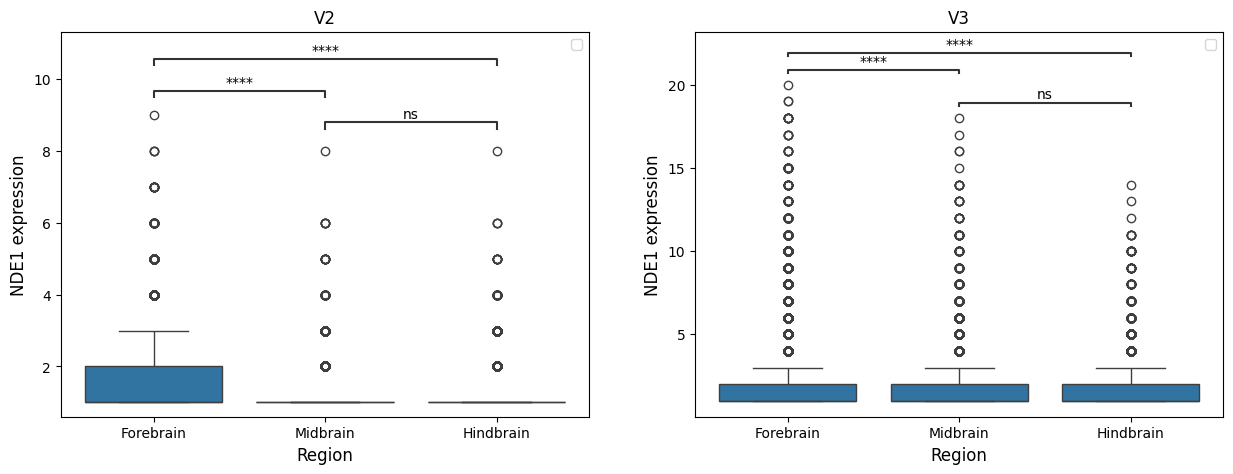

In [19]:

#Considering only cells that express NDE1
adata_RG_all_gt5_V2.obs['NDE1'] =  adata_RG_all_gt5_V2.layers['counts'][:,adata_RG_all_gt5_V2.var_names=='ENSG00000072864'].toarray().flatten()
adata_RG_all_gt5_V3.obs['NDE1'] =  adata_RG_all_gt5_V3.layers['counts'][:,adata_RG_all_gt5_V3.var_names=='ENSG00000072864'].toarray().flatten()
fig, axs = plt.subplots(1,2,figsize=(15, 5))
ax = sns.boxplot(ax = axs[0],x='Region1', y='NDE1',order= ['Forebrain','Midbrain','Hindbrain'] ,data=adata_RG_all_gt5_V2[np.where(adata_RG_all_gt5_V2.obs['NDE1']>0)[0],:].obs)
axs[0].set_xlabel("Region", fontsize= 12)
axs[0].set_ylabel("NDE1 expression", fontsize= 12)
axs[0].set_title("V2", fontsize= 12)
axs[0].grid(False)
axs[0].legend('') 

annotator = Annotator(ax, [('Forebrain', 'Midbrain'),( 'Midbrain', 'Hindbrain'),( 'Forebrain','Hindbrain')], data=adata_RG_all_gt5_V2[np.where(adata_RG_all_gt5_V2.obs['NDE1']>0)[0],:].obs, x='Region1', y='NDE1')
annotator.configure(test='Mann-Whitney')
annotator.apply_and_annotate()

ax = sns.boxplot(ax = axs[1],x='Region1', y='NDE1',order= ['Forebrain','Midbrain','Hindbrain'] ,data=adata_RG_all_gt5_V3[np.where(adata_RG_all_gt5_V3.obs['NDE1']>0)[0],:].obs)
axs[1].set_ylim(top=10) 
axs[1].set_xlabel("Region", fontsize= 12)
axs[1].set_ylabel("NDE1 expression", fontsize= 12)
axs[1].set_title("V3", fontsize= 12)
axs[1].grid(False)
axs[1].legend('') 

annotator = Annotator(ax, [('Forebrain', 'Midbrain'),( 'Midbrain', 'Hindbrain'),( 'Forebrain','Hindbrain')], data=adata_RG_all_gt5_V3[np.where(adata_RG_all_gt5_V3.obs['NDE1']>0)[0],:].obs, x='Region1', y='NDE1')
annotator.configure(test='Mann-Whitney')
annotator.apply_and_annotate()

plt.savefig('/miridan-data/miridan/proj/NDE1/boxplot_NDE1_expression_by_regions.pdf',dpi=200)


In [3]:
adata = sc.read_h5ad("/miridan-storage/miridan/wexac_backup/NDE1/NDE1_seurat_raw.analysis_30Jan23_25PCA_res06.h5ad")

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

KO_3 vs. KO_4: Mann-Whitney-Wilcoxon test two-sided, P_val:3.228e-01 U_stat=6.367e+05
KO_4 vs. W3_e3: Mann-Whitney-Wilcoxon test two-sided, P_val:2.193e-119 U_stat=1.009e+06
KO_3 vs. W3_e3: Mann-Whitney-Wilcoxon test two-sided, P_val:6.868e-150 U_stat=1.207e+06
KO_4 vs. W3_ep3: Mann-Whitney-Wilcoxon test two-sided, P_val:3.756e-98 U_stat=7.543e+05
KO_3 vs. W3_ep3: Mann-Whitney-Wilcoxon test two-sided, P_val:2.350e-123 U_stat=9.047e+05
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

KO_3 vs. KO_4: Mann-Whitney-Wilcoxon test two-sided, P_val:1.598e-20 U_stat=7.756e+05
KO_4 vs. W3_e3: Mann-Whitney-Wilcoxon test two-sided, P_val:1.533e-20 U_stat=1.950e+06
KO_3

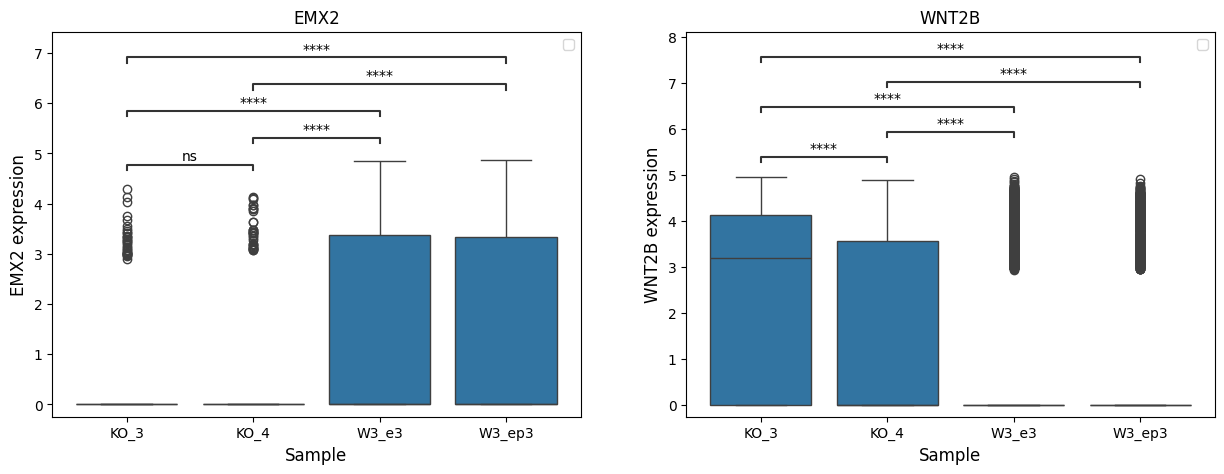

In [67]:
gene = 'EMX2'
adata.obs[gene] =  adata.X[:,adata.var_names==gene].toarray().flatten()
fig, axs = plt.subplots(1,2,figsize=(15, 5))
ax = sns.boxplot(ax = axs[0],x='corrected.ident', y=gene,order= ['KO_3','KO_4','W3_e3','W3_ep3'] ,data=adata.obs)
axs[0].set_xlabel("Sample", fontsize= 12)
axs[0].set_ylabel(gene+" expression", fontsize= 12)
axs[0].set_title(gene, fontsize= 12)
axs[0].grid(False)
axs[0].legend('') 
#add_stat_annotation(ax, data=adata_RG_all_gt5_V3[np.where(adata_RG_all_gt5_V3.obs['NDE1']>0)[0],:].obs, x='Region1', y='NDE1',order= ['Forebrain','Midbrain','Hindbrain'],
#                    box_pairs=[('Forebrain', 'Midbrain'),( 'Midbrain', 'Hindbrain'),( 'Forebrain','Hindbrain')],
#                    test='Mann-Whitney-gt', text_format='star', loc='outside', verbose=2)

annotator = Annotator(ax, [('KO_3','KO_4'),( 'KO_3','W3_e3'),( 'KO_3','W3_ep3'),( 'KO_4','W3_e3'),( 'KO_4','W3_ep3')], data=adata.obs, x='corrected.ident', y=gene)
annotator.configure(test='Mann-Whitney')
annotator.apply_and_annotate()
gene= 'WNT2B'
adata.obs[gene] =  adata.X[:,adata.var_names==gene].toarray().flatten()
ax = sns.boxplot(ax = axs[1],x='corrected.ident', y=gene,order= ['KO_3','KO_4','W3_e3','W3_ep3'] ,data=adata.obs)
axs[1].set_xlabel("Sample", fontsize= 12)
axs[1].set_ylabel(gene+" expression", fontsize= 12)
axs[1].set_title(gene, fontsize= 12)
axs[1].grid(False)
axs[1].legend('') 
#add_stat_annotation(ax, data=adata_RG_all_gt5_V3[np.where(adata_RG_all_gt5_V3.obs['NDE1']>0)[0],:].obs, x='Region1', y='NDE1',order= ['Forebrain','Midbrain','Hindbrain'],
#                    box_pairs=[('Forebrain', 'Midbrain'),( 'Midbrain', 'Hindbrain'),( 'Forebrain','Hindbrain')],
#                    test='Mann-Whitney-gt', text_format='star', loc='outside', verbose=2)

annotator = Annotator(ax, [('KO_3','KO_4'),( 'KO_3','W3_e3'),( 'KO_3','W3_ep3'),( 'KO_4','W3_e3'),( 'KO_4','W3_ep3')], data=adata.obs, x='corrected.ident', y=gene)
annotator.configure(test='Mann-Whitney')
annotator.apply_and_annotate()
plt.savefig('/miridan-data/miridan/proj/NDE1/boxplot_WNT2B_EMX2_expression_by_samples.pdf',dpi=200)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

KO_3 vs. KO_4: Mann-Whitney-Wilcoxon test two-sided, P_val:5.188e-02 U_stat=6.677e+05
KO_4 vs. W3_e3: Mann-Whitney-Wilcoxon test two-sided, P_val:1.106e-58 U_stat=2.067e+06
KO_3 vs. W3_e3: Mann-Whitney-Wilcoxon test two-sided, P_val:8.003e-111 U_stat=2.694e+06
KO_4 vs. W3_ep3: Mann-Whitney-Wilcoxon test two-sided, P_val:1.790e-33 U_stat=1.400e+06
KO_3 vs. W3_ep3: Mann-Whitney-Wilcoxon test two-sided, P_val:7.898e-64 U_stat=1.814e+06
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

KO_3 vs. KO_4: Mann-Whitney-Wilcoxon test two-sided, P_val:1.545e-10 U_stat=7.384e+05
KO_4 vs. W3_e3: Mann-Whitney-Wilcoxon test two-sided, P_val:1.097e-65 U_stat=2.198e+06
KO_3 v

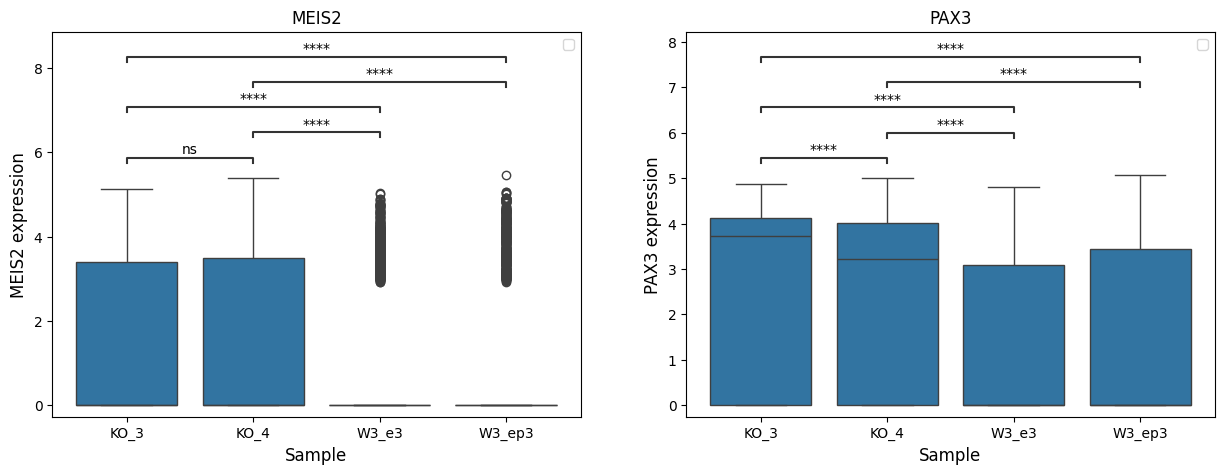

In [6]:
gene = 'MEIS2'
adata.obs[gene] =  adata.X[:,adata.var_names==gene].toarray().flatten()
fig, axs = plt.subplots(1,2,figsize=(15, 5))
ax = sns.boxplot(ax = axs[0],x='corrected.ident', y=gene,order= ['KO_3','KO_4','W3_e3','W3_ep3'] ,data=adata.obs)
axs[0].set_xlabel("Sample", fontsize= 12)
axs[0].set_ylabel(gene+" expression", fontsize= 12)
axs[0].set_title(gene, fontsize= 12)
axs[0].grid(False)
axs[0].legend('') 
#add_stat_annotation(ax, data=adata_RG_all_gt5_V3[np.where(adata_RG_all_gt5_V3.obs['NDE1']>0)[0],:].obs, x='Region1', y='NDE1',order= ['Forebrain','Midbrain','Hindbrain'],
#                    box_pairs=[('Forebrain', 'Midbrain'),( 'Midbrain', 'Hindbrain'),( 'Forebrain','Hindbrain')],
#                    test='Mann-Whitney-gt', text_format='star', loc='outside', verbose=2)

annotator = Annotator(ax, [('KO_3','KO_4'),( 'KO_3','W3_e3'),( 'KO_3','W3_ep3'),( 'KO_4','W3_e3'),( 'KO_4','W3_ep3')], data=adata.obs, x='corrected.ident', y=gene)
annotator.configure(test='Mann-Whitney')
annotator.apply_and_annotate()
gene= 'PAX3'
adata.obs[gene] =  adata.X[:,adata.var_names==gene].toarray().flatten()
ax = sns.boxplot(ax = axs[1],x='corrected.ident', y=gene,order= ['KO_3','KO_4','W3_e3','W3_ep3'] ,data=adata.obs)
axs[1].set_xlabel("Sample", fontsize= 12)
axs[1].set_ylabel(gene+" expression", fontsize= 12)
axs[1].set_title(gene, fontsize= 12)
axs[1].grid(False)
axs[1].legend('') 
#add_stat_annotation(ax, data=adata_RG_all_gt5_V3[np.where(adata_RG_all_gt5_V3.obs['NDE1']>0)[0],:].obs, x='Region1', y='NDE1',order= ['Forebrain','Midbrain','Hindbrain'],
#                    box_pairs=[('Forebrain', 'Midbrain'),( 'Midbrain', 'Hindbrain'),( 'Forebrain','Hindbrain')],
#                    test='Mann-Whitney-gt', text_format='star', loc='outside', verbose=2)

annotator = Annotator(ax, [('KO_3','KO_4'),( 'KO_3','W3_e3'),( 'KO_3','W3_ep3'),( 'KO_4','W3_e3'),( 'KO_4','W3_ep3')], data=adata.obs, x='corrected.ident', y=gene)
annotator.configure(test='Mann-Whitney')
annotator.apply_and_annotate()
plt.savefig('/miridan-data/miridan/proj/NDE1/boxplot_MEIS2_PAX3_expression_by_samples.pdf',dpi=200)


In [35]:
adata.X[:,adata.var_names=='FOXG1'].flatten()

array([], dtype=float64)